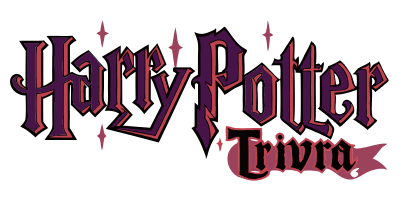

<div style="background-color: #f0e6f7; padding: 10px;">
    <h2 style="text-align:center; color:purple;">Harry Potter Trivia Game</h2>
    <h3 style="text-align:center; color:purple;">Data preparation and EDA</h3>
</div>

# 1. Introduction

Ready your wands! This project aims to conjure an engaging Harry Potter Trivia game. Before the magic can truly begin with the Phase 1 CLI-MVP, we must first understand the key ingredient - the trivia dataset. This notebook covers the foundational step of cleaning and performing Exploratory Data Analysis (EDA) on the public dataset that powers the game. The main objective here is to understand the data's characteristics and produce a clean, processed CSV file ready for the Phase 1 command-line interface (CLI) MVP; it will also inform subsequent NLP work in Phase 2.

A public dataset of trivia questions from Huggingface is used here. The dataset was downloaded using the `download_data.py` script, the train and test split were combined and stored as a single csv file from [saracandu/harry-potter-trivia-human](https://huggingface.co/datasets/saracandu/harry-potter-trivia-human/tree/main) on January 25, 2025. 

#### Workflow Summary

The main stages covered in this notebook include:
1. **Data Preparation:** Cleaning and preparing the raw trivia data (handling nulls, duplicates, types, feature selection).
2. **Basic Exploratory Data Analysis (EDA):** Initial analysis and visualization of the questions and answers in the cleaned dataset.
3. **Keyword Generation:** Tokenizing question and answer text using lemmatization to create keyword features.
3. **In-depth EDA:** Grandular analysis and visualization of the cleaned dataset with the generated keywords.
4. **Finalize dataset for CLI-MVP:** Create a clean dataset csv file that can be used in the phase-1, CLI-MVP version of the game.  Provide a basis for expanding the trivia question and answer dataset in future development phases.


# Table of Contents

1. [Introduction](#1-Introduction)<br>
2. [Glossary of key terms](#2-Glossary-of-key-terms)<br>
3. [Setup and imports](#3-Setup-and-imports)<br>
4. [Data preparation](#4-Data-preparation)<br>
**PART-1**: Basic EDA<br>
5. [Basic Exploratory Data Analysis (EDA)](#5-Basic-EDA-of-the-cleaned-dataset)<br>
    5.1. [Overview](#51-Overview)<br>
    5.2. [Answer lengths](#52-Answer-lengths)<br>
    5.3. [Question lengths](#53-Question-lengths)<br>
    5.4. [Question and answer length correlations](#54-question-and-answer-length-correlation)<br>
**PART-2**: Feature engineering<br>
6. [Keyword feature engineering](#6-Keyword-feature-engineering) <br>
**PART-3**: In-depth EDA based on question keywords and N-grams <br>
7. [EDA based on keywords](#7-EDA-based-on-keywords)<br>
    7.1. [Unique keyword frequency](#71-unique-keyword-frequency) <br>
    7.2. [Factual recall questions](#72-factual-recall-questions)<br>
    7.3. [Questions that do not have factual recall keywords](#73-questions-that-do-not-have-factual-recall-keywords)<br>
    7.4. [Correlation summary: Q&A lengths by question keyword](#74-Corrleation-summary-qa-lengths-filtered-by-question-keyword)<br>
    7.5. [Common N-grams in the dataset](#75-Common-n-grams-in-the-dataset)<br>
8. [Content Similarity Analysis](#8-content-similarity-analysis)<br>
    8.1. [Question-Answer pariwise comparison](#81-question-answer-q-a-pairwise-comparison)<br>
    8.2. [Question-Question comparison](#82-question-question-q-q-comparison)<br>
    8.3. [Answer-Answer comparison](#83-answer-answer-a-a-comparison)<br>
9. [Feature Engineering based on in-depth EDA Findings](#9-Feature-engineering-from-in-depth-eda-findings)<br>
    9.1. [Dataset cleaning based on findings from the in-depth EDA](#91-Dataset-cleaning-based-on-findings-from-in-depth-eda)<br>
    9.2. [Add question type tags to the dataset](#92-Add-question-type-tags-to-dataset)<br>
**PART-4**: Quality assurance and finalization <br>
10. [Data quality assurance and finalization](#10-Data-quality-assurance-and-finalization)<br>
    10.1. [Automated heuristics](#101-Automated-heuristics)<br>
    10.2. [Manual review](#102-Manual-review)<br>
    10.3. [Status map of dataset](#103-Status-map-of-the-dataset)<br>
11. [Summary and key findings](#10-summmary-and-key-findings)<br>
    11.1. [Summary](#111-Summary)<br>
    11.2. [Key findings](#112-key-findings)<br>
**PART-5**: Dataset preparation for export to CLI-MVP<br> 
12. [Data dictionary](#12-Data-dictionary)<br>
13. [Next steps and data export](#13-Next-steps-and-data-export)<br>

# 2. Glossary of key terms

To ensure clarity and consistency, the following terms are defined within the context of this analysis:

|Term | Abbreviation | Description|
|-|-|-|
|Factual Recall (Question) | FR | Question seeking specific objective info (name, date, place, etc.). Identified by keywords such as 'What', 'Who', etc. |
| Open-Ended Question| OEQ| Question seeking explanation, opinion, or procedure, often identified by keywords like 'Why' or 'How'.|
| Not Applicable | N/A | Not Assigned / Not Applicable (in context). Used in columns like factual_recall_keyword to label questions not initially matched with a primary factual-recall keyword. These were subsequently analyzed as 'Non-Factual Recall' or other types.| 
| Question Type| QT | Classification assigned (e.g., Factual-Recall, Open-Ended) based primarily on keywords/phrasing, answer type |
| Question Keyword | QK | Lemmatized token from question text used for analysis/filtering (standard stopwords removed, interrogatives kept). |
| MVP of game| CLI-MVP | The first phase prototype of the Harry Potter Trivia game (Command Line Interface - Minimum Viable Product) |  

# 3. Setup and imports

Import the necessary external packages as well as internal project environment configuration and custom helper and utility methods from project modules.

In [1]:
# External libraries and packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re
from collections import Counter, OrderedDict
from nltk import pos_tag
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from pprint import pprint
import networkx as nx

# Import the project environment configurations and load them.
import dotenv
dotenv.load_dotenv()  

# Import custom methods from project scripts
from utils import utils_paths as up
import eda_scripts as eda

<a href="#Table-of-Contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 4. Data preparation

To start, the dataset quality needs be to checked and addressed suitably. These involves checking the size of the dataset to make sure there are enough questions, as well as missing data (nulls) and duplicates. 

In [2]:
# convert csv file to dataframe
project_root = up.find_project_root()
rawcsv_path = project_root / "data" / "original_dataset_DONT_TOUCH"/"harry_potter_trivia_questions_HFdataset.csv"
raw_df = pd.read_csv(rawcsv_path)
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1279 entries, 0 to 1278
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1279 non-null   object
 1   answer    1279 non-null   object
 2   text      1279 non-null   object
dtypes: object(3)
memory usage: 30.1+ KB


The dataset has 1279 rows and 3 columns. 

In [3]:
raw_df.sample(5)

,question,answer,text
960,What did Professor Snape tell Harry could Deto...,Bezoar,<s>[INST] What did Professor Snape tell Harry ...
735,What does solitary 'X' classification mean?,Boring,<s>[INST] What does solitary 'X' classificatio...
1056,What was the name of the wizard who created th...,Nicolas Flamel,<s>[INST] What was the name of the wizard who ...
546,Who did not compete in the Triwizard Tournament?,Fred,<s>[INST] Who did not compete in the Triwizard...
985,Who is the Divination professor?,Professor Trelawney,<s>[INST] Who is the Divination professor? [/I...


The question and answers are in the first two columns. The third `text` column looks like it is the question and answers tokenized for LLM modelling.  Let's look a the full entry of the `text` column in the first row to see if it can be useful.

In [4]:
# Look at the contents of the first row, third column record (i.e. text column) without being clipped.
print(raw_df.iloc[0,2])  

<s>[INST] What are the three European wizarding schools that participate in the Triwizard Tournament? [/INST] Hogwarts, Beauxbatons, and Durmstrang. </s>


This confirms that the third column combines the question and answer with tokens for prompting an LLM model. It is not needed for this project, so the third column can be removed.

In [5]:
# Drop the `text` column:
raw_df = raw_df.drop(columns=['text'])
# Sanity check - confirm column has been dropped
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1279 entries, 0 to 1278
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1279 non-null   object
 1   answer    1279 non-null   object
dtypes: object(2)
memory usage: 20.1+ KB


We can now check if there are any nulls in the dataset?

In [6]:
# Sanity check: 
raw_df.isna().sum()

question    0
answer      0
dtype: int64

Good news - no missing data. The next step is to check for duplicated rows.

In [7]:
# check for duplicates
raw_df.duplicated().sum()

np.int64(194)

There are 194 duplicates in the dataset. We can confirm this by taking a closer look at the rows and how many times they appear in the dataset and then delete them.

In [8]:
# Find duplicates based on all columns
duplicates = raw_df[raw_df.duplicated(keep=False)]
# Count occurrences of each duplicate row
duplicate_counts = duplicates.groupby(duplicates.columns.tolist()).size().reset_index(name='Count')
# Display the counts of each duplicate
print(duplicate_counts)

                                             question           answer  Count
0                       A Firebolt is a type of what?            Broom      5
1                         A Nimbus is a type of what?            Broom      5
2   According to Madam Hooch, which of the followi...        Long hair      5
3   Before Dumbledore, who was Headmaster of Hogwa...   Armando Dippet      2
4        Catching what object ends a Quidditch match?    Golden Snitch      5
..                                                ...              ...    ...
64  Who previously held Snape's post as Potions Ma...  Horace Slughorn      2
65                  Who previously held Snape's post?  Horace Slughorn      2
66  Who was the first witch or wizard to hatch a b...   Herpo the Foul      2
67        Why would you need to switch brooms midair?    Broom failure      5
68  You wouldn't know anything about this. Name a ...     Using polish      5

[69 rows x 3 columns]


So let's go ahead and delete the unnecessary duplicate rows.

In [9]:
trivia_df = raw_df.drop_duplicates(keep='first').reset_index(drop=True)
trivia_df.shape

(1085, 2)

After dropping the duplicates, we have 1085 unique questions and answer pairs in the dataset. A decent size for the MVP.
Finally, let's convert the `question` and `answer` columns to `str` for clarity, type safety, and make sure the `str` methods are available for them.

In [10]:
# convert columns from 'object` to `str`
trivia_df = trivia_df.astype({
    'question': 'string',
    'answer': 'string'})
print("\nData types after conversion:")
trivia_df.info()


Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1085 non-null   string
 1   answer    1085 non-null   string
dtypes: string(2)
memory usage: 17.1 KB


We can have a quick look at the state of the cleaned dataframe, save as a csv, and move on to exploration. 

In [11]:
trivia_df.head()

,question,answer
0,What are the three European wizarding schools ...,"Hogwarts, Beauxbatons, and Durmstrang."
1,When was Hogwarts founded?,10th century
2,What is a Wronski Feint?,Pretending to dive for the Snitch
3,You wouldn't know anything about this. Name a ...,Using polish
4,Harry first took the Knight Bus in The Prisone...,14 sickles.


---

#### 💾 Checkpoint 1: saving clean dataset
<details>
<summary> Click here for checkpoint details and <b>warning!</b> </summary>

The DataFrame is now cleaned and ready for EDA. Saving the current state.
<br>
> **⚠️ Caution: Manual Intervention Required for Saving Files**
>
> Please be aware that the `save_dataframe_to_csv` utility is designed to prevent accidental data loss. It **does not automatically overwrite** previously saved files.
>
> If you run a cell that calls this function and the output file (based on `filename_base`, `version`, and `subfolder`) already exists, the save operation will be skipped. You will see a message indicating this.
>
> **To save your latest data, you must manually intervene by either:**
> 1.  Deleting the older version of the CSV file from the file system.
> 2.  Modifying the `version` argument (or `filename_base`) in your function call to create a new, unique filename.

The following code saves the cleaned DataFrame to <code>data/project_datasets/</code> based on the selecte saved arguments.
</div>
</details>

In [12]:
# Using utils.paths.py module -> prevents overwritting csv file unless manually done.

# Save arguments
dataframe_to_save = trivia_df
name_for_csvfile = 'clean_trivia_dataset'
csv_version = 'v0'
csv_subfolder = 'project_datasets'

# Save csv  file with custom functions and defined save arguments
up.save_dataframe_to_csv(dataframe_to_save, name_for_csvfile, csv_version, csv_subfolder)

File already exists at: data/project_datasets/clean_trivia_dataset_v0.csv. Skipping save.


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

---

<div align="center" style="background-color: #f0e6f7; padding: 10px;">
    <span style="color:purple; font-size:32px;">Part-1: Basic Exploratory Data Analysis (EDA)</span>
</div>

# 5. Basic EDA of the cleaned dataset

We need to inspect and understand the dataset to decide whether it is suitable for the trivia game. Some questions we can  consider:
- Are there enough quality and diverse questions and answers?
- Does it cover a wide-enough range of Harry Potter content to make the game interesting?
- How verbose are the questions and answers? Are they grammatically correct and easy to understand?
- Are there various degrees of difficulty to the questions? 
- Could the length give an idea of the difficulty of the questions? What else?
- Do longer questions result in longer answers? 
- What type of questions are there? What about the answers? is categorization possible?
- Are there other patterns we can discern?

We can start the data exploration by looking at the questions and answer columns analytically. One characteristic they have in common is length (ie. word count). We can look at the descriptive statistics and distributions of the lengths. We can tokenize the words and look at question types and N-grams to get contextual understanding of the questions and answers. And we can also look at the relationship between questions and answers. 

## 5.1. What can we learn from the question and answer lengths?

In [13]:
# extract the length of each question and answer using the helper function from the eda_scripts module
question_lengths = eda.get_clean_word_counts(trivia_df, "question")
answer_lengths = eda.get_clean_word_counts(trivia_df, "answer")

length_analysis = pd.DataFrame({"question": question_lengths, "answer": answer_lengths}).describe()
print(length_analysis)

          question       answer
count  1085.000000  1085.000000
mean      9.851613     2.659908
std       4.326515     2.657494
min       3.000000     1.000000
25%       7.000000     1.000000
50%       9.000000     2.000000
75%      12.000000     3.000000
max      31.000000    25.000000


The answers are generally shorter then the questions. Most answers are about 1 to 3 words while most questoins are about 9 words. 

We can also look at the distributions visually.

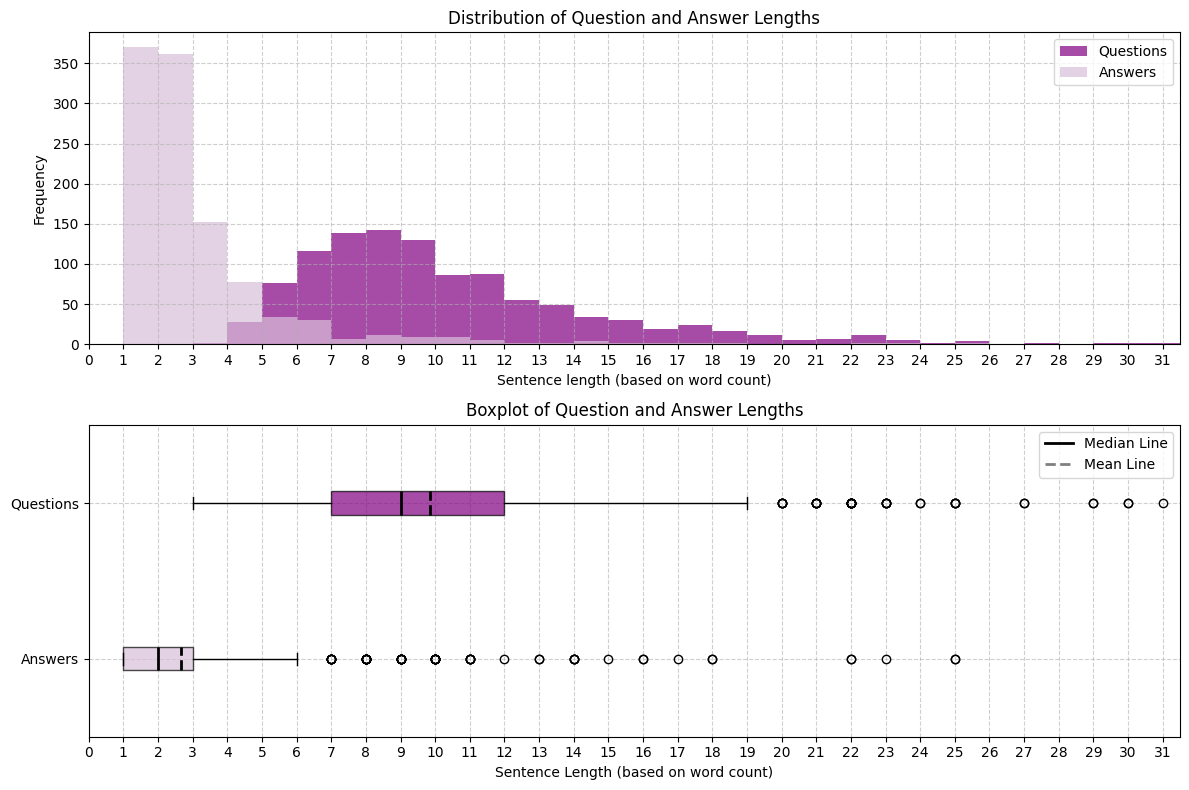

In [14]:
# let's plot the distribution of lengths of questions and answers
eda.plot_qa_len_distributions(question_lengths, answer_lengths)

From the plot above:
- Both questions and answers have longer sentences as outliers, perhaps they can be made more concise / clearer?
- The questions looks like a right-skewed normal distribution
- Most questions are ~12 words or less (75% percentile)
- Most questions fall between 7 and 12 words (inter-quartile range), with a mean of 9 words.
- The answers is also a very right-skewed distribution with a rapid decay.
- Most answers are ~3 words or less (75% percentile)
- One word answers are the most common.
- So the answers are generally short words that should make answer checking simpler.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

### 5.1.1 Answer lengths

An analysis of answer lengths within the dataset helps set expectations for complexity in player response within the trivia game. The distribution of word counts indicates whether typical player input is likely to be short (mirroring the dataset's concentration of 1-3 word answers) or will sometimes include much longer responses (reflecting the dataset's long tail).Establishing a clear definition for 'short' and 'long' answers, based on the dataset's statistical properties, enables a structured analysis. 

 The descriptive statistics in [section 5.1](#51-overview) show 75% of answers have 3 words or fewer (Q3 is 3 words) and an interquartile range (IQR) of 2 words. The outlier threshold (Q3 + 1.5*IQR = 6) provides a suitable cutoff such that: 
- *answers qualify as "short" with 6 or fewer words*, 
- *answers qualify as "long" with 7 or more words*.

Beyond length, examining the diversity in answers is also crucial. This can influences gameplay engagement and the requirements for the answer-checking system. 
- A diverse answer set indicates it covers a good range of the Harry Potter universe (characters, spells, places etc.) and less  repetition which will make the in-game experience more immersive and engaging. 
- Along with length, the type and obscurity of the answer can help determine the range of difficulty within the dataset.
- High diversity could also mean that the same thing is being said in different ways. For example a question with the answer "Professor Albus Dumbledore" could have synonym like answers such as "Albus", "Albus Dumbledore", "the headmaster" etc. This would inform the design considerations for semantic-similarity analysis in later project phases.
- Ultimately, this analysis of answer characteristics contributes to a fuller understanding of the dataset, helping confirm its suitability for the MVP by verifying content variety and informing the design scope for answer evaluation.

In [15]:
# Total number of answers:
total_answers = len(answer_lengths)

# Categorize word counts into bins:
bin_edges = [0, 3, 11, np.inf]
bin_labels = ['1-3 words', '4-11 words', '12+ words']
answer_length_bins = pd.cut(answer_lengths, bins=bin_edges,labels=bin_labels,right=True, # (x, y], upper limit is inclusive, lower is not
                            include_lowest=False) # Exclude 0 as wordcount

# Calculate frequencies and percentages for these bins
binned_counts = answer_length_bins.value_counts().sort_index()
binned_percentages = (binned_counts / total_answers) * 100
# Create a DataFrame for cleaner display of binned results
summary_bin_df = pd.DataFrame({'Count': binned_counts,'Percentage (%)': binned_percentages.round(2) })

# Display summary
print(" Summary of answer length frequencies:\n",
      '-'*60)
print(f'\nTotal number of answers analyzed: {total_answers}')
count_more_than_3 = binned_counts.get('4-11 words', 0) + binned_counts.get('12+ words', 0)
print(f'The number of answers with a word count more than 3: {count_more_than_3}')
print("\nAnswer Length Distribution by Bins:")
display(summary_bin_df)
# Verify percentages add to ~100%
print(f'\nTotal Percentage (check): {binned_percentages.sum():.2f}%')

 Summary of answer length frequencies:
 ------------------------------------------------------------

Total number of answers analyzed: 1085
The number of answers with a word count more than 3: 201

Answer Length Distribution by Bins:


,Count,Percentage (%)
answer,,
1-3 words,884,81.47
4-11 words,183,16.87
12+ words,18,1.66



Total Percentage (check): 100.00%


Majority (81%) of the answers are short (1 to 3 words). The interquaritile range is between 1 to 3 words. The distribution is right-skewed with a rapid decay. About 17% has answer lengths between 4 to 11 words while the remaining 2% have a word count of 12 or more. The maximum answer length is 25 words.
 - For analysis, answers with a word count of 6 (Q3 + 1.5* IQR) was used as cutoff for categorizing answers into short (wc <= 6) and long answers (wc > 6).
- The short anwerer are generally unique indicating there is good variety. The short answer will also simplify checking answers. 
   

**Short answers**:

In [16]:
# We will set a threshold for length: Answers length <= 6 are short, rest are long.
ans_len_threshold = 6
# create a dict of with answer len as key
answer_n_wc = {n: trivia_df[answer_lengths == n] for n in range(1,ans_len_threshold+1,1)}
# create a nested dict so that we can include percentage of small ans to each wordcount
unique_answers_dict = {
    n: {
        'num_unique': (num_unique := answer_n_wc[n]['answer'].nunique()),
        'total_answers': (total := answer_n_wc[n]['answer'].count()),
        'percentage': round(num_unique / total * 100, 2)
    }
    for n in range(1, 7)
 }
unique_answers_df = pd.DataFrame(unique_answers_dict).T
unique_answers_df['percentage'] = unique_answers_df['percentage'].round(0).astype(int)
unique_answers_df[['num_unique','total_answers']] = unique_answers_df[['num_unique','total_answers']].astype(int)  
unique_answers_df

,num_unique,total_answers,percentage
1,310,370,84
2,304,362,84
3,141,152,93
4,73,78,94
5,34,34,100
6,29,30,97


We can see that most of the short-word answers have a hight count of unique values for a given length; we can infer that there is not a lot of repitition. This is a good high level confirmation that there is diversity in the dataset but we will have to take a closer look to actually confirm if this true. For example `Albus` and `Dumbledore` are unique terms  but refer to the same person. We will need more granual and contextual understanding to fully understand the diversity of the dataset.

**Long answers:**

In [17]:
# display the full content of all columns without truncation
pd.set_option('display.max_colwidth', None)

# filter for long answers
long_answers= trivia_df[answer_lengths > ans_len_threshold]

# Display results
print(f"There are {long_answers['answer'].count()} answers with a word count greater than {ans_len_threshold}\n\n")
print(long_answers['answer'].sample(10))

There are 59 answers with a word count greater than 6


265                                                                                                                                     Remus Lupin, Peter Pettigrew, Sirius Black, and James Potter.
439                                                                                                                                          Freshly mown grass, mint toothpaste, and fresh parchment
490                                                                     “Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much.”
77                                                                                                                                 His aunt and uncle, Petunia and Vernon Dursley, and cousin Dudley.
824                                                                                                                                                     

**Notes**:
- Some of the longest (including the most long) answers are lists.
- A few answers are just wordy.
- Others need to be long to give the full answer.

In [18]:
# Let's look at long answer outliers:
long_answers= trivia_df[answer_lengths >= 17]

# Display the number of unique words in the one-word answers and total number of one-word answers
print(f"The number of outlier long answers: {long_answers.shape[0]}\n",
      f"\n The outlier long answers are:\n\n{long_answers['answer']}")

The number of outlier long answers: 8
 
 The outlier long answers are:

316                                                                                     38. It was 36 (one less than last year), but then Mrs. Dursley bought him two new presents to make up for it.
414                                                                                                                                    6-2-4-4-2. (Bonus: This spells M-A-G-I-C on a phone's keypad.)
490                                                                     “Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much.”
581                                                                                                 He uses the Patronus Charm in front of a Muggle (Dudley, and only because there were Dementors!).
627                                                                      In the book, the mummy trips on its wrappings. In the movie, it

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

### 5.1.2. Question lengths

**What are the main trends in question lengths?**


In [19]:
q1 = question_lengths.quantile(0.25)
q3 = question_lengths.quantile(0.75)
iqr = q3 - q1

short_questions = trivia_df[question_lengths < q1]
common_len_questions = trivia_df[(question_lengths >= q1)&(question_lengths<= q3)]
outlier_threshold = q3 + 1.5*iqr
long_questions= trivia_df[(question_lengths > q3) & (question_lengths <= outlier_threshold)]
vlong_outlier_questions = trivia_df[question_lengths > outlier_threshold]

print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}, Long outlier threshold: {outlier_threshold}")
print(f"Number of short questions (< Q1): {len(short_questions)}")
print(f"Number of common length questions (Q1-Q3): {len(common_len_questions)}")
print(f"Number of long questions (long outlier threshold < word count< Q3): {len(long_questions)}")
print(f"Number of very long (outlier) questions (> Q3 + 1.5*IQR): {len(vlong_outlier_questions)}")

Q1: 7.0, Q3: 12.0, IQR: 5.0, Long outlier threshold: 19.5
Number of short questions (< Q1): 222
Number of common length questions (Q1-Q3): 638
Number of long questions (long outlier threshold < word count< Q3): 184
Number of very long (outlier) questions (> Q3 + 1.5*IQR): 41


In [20]:
# what do the short questions look like? 
short_questions.sample(10)

,question,answer
929,What is Lily Potter's birthday?,"Jan. 30, 1960"
39,What does 'Colloportus' do?,Lock and seal doors
176,What item cannot be conjured?,Food
1027,What does the Knitting Charm enchant?,The knitting needles.
301,What are the colors of Ravenclaw?,Blue and bronze
398,Who is Stan Shunpike?,The conductor of the Knight Bus
1038,Where is the Hufflepuff common room?,By the kitchens
164,Which of these plants bloom instantly?,Puffapod
602,Where does the Sopophorous Plant grow?,Gloomy marshlands.
1043,Who is the Flying instructor?,Madam Hooch


In [21]:
# What are the shortest questions like? do they make sense?
short_questions.loc[question_lengths==question_lengths.min()]

,question,answer
352,Who kills Dobby?,Bellatrix Lestrange
881,What is arithmancy?,Numerology


The short questions are very concise and specific typically asking for facts so their answers seem to be equally short and precise. The shortest questions, with a wordcount, seem to be the same.  
What about the common length questions, that fall within the inter-quartile range?

In [22]:
common_len_questions.sample(10)

,question,answer
95,Which of these is not a type of broom?,Occamy
194,How old was Harry when he got his first letter from Hogwarts?,Eleven
503,Which star is the brightest in the night sky?,Sirius.
124,Which mischievous character from the books did not feature in the movies?,Peeves the Poltergeist
506,What's a telltale sign that mandrakes have matured?,They move into each other's pots
546,What piece of equipment is essential when re-potting baby Mandrakes?,Earmuffs
731,What is the incantation for the tongue-tying curse?,Mimblewimble.
497,Who is the matron of the orphanage where Voldemort grows up?,Mrs. Cole
981,How would you describe a Pixie's voice?,Shrill
326,Who was the original owner of the locket Horcrux?,Salazar Slytherin


The questions follow the pattern of the short questions and are generally to the point and concise. However, there are few samples that showed truncated multiple choice questions (for example Q.175, Q.630, Q.327) - these should be looked at closer later and addressed in the [data quality section](#9-Data-quality-assurance-and-finalization). Again these are factual questions, with generally short (1 to 3 word) answers.

In [23]:
long_questions['question'].sample(5)

573                                You should cover your ears when this mature plant starts crying. Name that plant!
74                                 I'd be surprised if you knew this. what's the first step of flying on your broom?
815                           In the Chamber of Secrets, the tears of the Phoenix cured the Poison of what creature?
816    In Book 4, what magical creature does Harry answer a riddle from in the maze during the Triwizard Tournament?
67             What is the name of the dragon that Harry Potter faces in the first task of the Triwizard Tournament?
Name: question, dtype: string

In [24]:
vlong_outlier_questions['question'].sample(5)

568                                 What do Harry, Ron and Hermione find in the locked cabinet of a writing desk at the Order of the Phoenix Headquarters?
957                        Hermione places a jinx on the piece of parchment members of Dumbledore’s Army sign. What happens to those who betray the group?
288                                                        In the epilogue to the book, who says, “Don’t let it worry you. It’s me, I’m extremely famous.”
266     What is the name of the powerful and dangerous artifact that Voldemort creates in the Harry Potter series by splitting his soul into seven pieces?
1033                                    Voldemort stole Helga Hufflepuff's cup from an old woman named Hepzibah Smith. What was the name of her house-elf?
Name: question, dtype: string

In [25]:
vlong_outlier_questions.sample(5)

,question,answer
828,"On the wall across from the Room of Requirement, there is a tapestry showing a wizard trying to teach trolls ballet. What's his name?",Barnabus the Barmy.
812,This real-life library served as the restricted section of the Hogwarts library in the film version. Which is it?,The Bodleian Library at Oxford University
385,Lily Potter once gave Professor Slughorn a bowl with a lily that turned into a goldfish. What was the goldfish’s name?,Francis
356,"Snape grilled Harry about this on his first day in Potions. Monkshood and wolfsbane are the same plant, also known as what?",Aconite.
414,The visitor’s entrance to the Ministry of Magic is an abandoned red telephone booth in London. What is the five-digit code you must dial to get in?,6-2-4-4-2. (Bonus: This spells M-A-G-I-C on a phone's keypad.)


>📝  **Notes**:
>1. Majority of the answers are short words (75% of words are 3 words or less). This would make checking answers for these questions relatively straight forward.
>2. There are 179 answers that are longer then 3 word. A lot of them can be shortened to fewer ones. Can write a script with NER to update these later on to have a cleaner dataset.
>3. There are 7 outlier questions, some of which can be simpliefied.
>4. The questions are
> 
> Overall we can consider the quality of the questions and answer to be good with a good sized dataset for the the trivia game and a nice variety in those questions. It will be interesting to see what the difficulty of those questions are like.
> <br>


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 5.2. Question and answer length correlation

A key part of the analysis is to explore whether there is a statistically significant relationship between the question and answer lengths. We can start with a high-level (entire dataset) perspective and see if there is any general linear trend between how long a question is and how long its answer is. This can give us a baseline idea of any trend that we can fine-tune as we dive further into the EDA.

We can frame this by first testing our null hypothesis:

- *Null hypothesis ($H_0$):* There is no statistically significant relationship between the length of a question and the length of its answer.
- *Alternative hypothesis ($H_1$):* There is a relationship between the lengths of questions and their answers.

Since this is an aggregated view, there might be hidden underlying patterns that can't be discerned yet. This is investigated at a more granular level in the in-depth EDA ([section 6](#6-eda-based-on-keywords).)




Correlation between all question and answer lengths:
----------------------------------------------------------------------
* r-value: 0.09, p-value: 0.002
* Interpretation: Statistically significant (correlation is Very Weak)
----------------------------------------------------------------------


Scatter Plot with Regression Line:


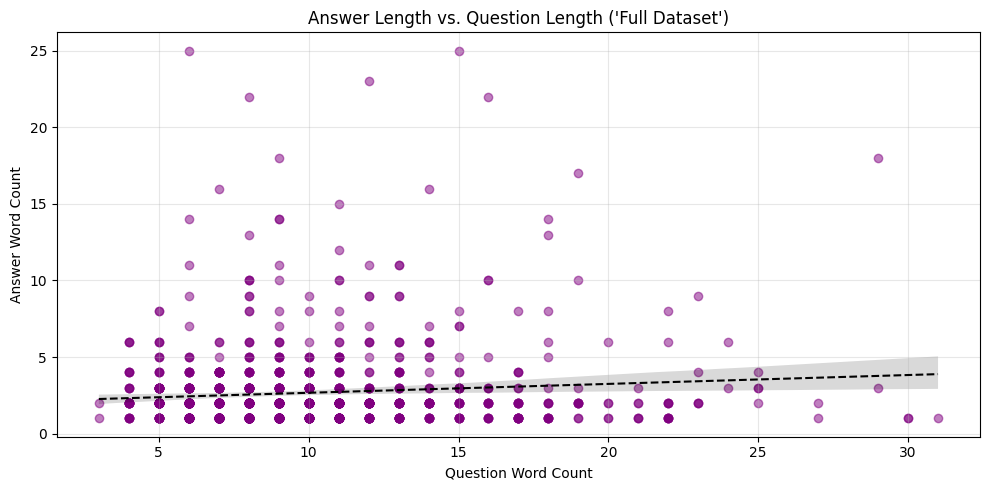

In [26]:
# Use the custom helper functions from the eda_scripts module:
# 1. Calculate r and p-values  
r_all, p_all = eda.calculate_correlation(question_lengths, answer_lengths)
# 2. Interpret the correlation and print results
corr_interpretation, r_strength = eda.interpret_correlation(r_all, p_all)
print(f"\nCorrelation between all question and answer lengths:\n"
      f"{'-'*70}\n"
      f"* r-value: {r_all:.2f}, p-value: {p_all:.3f}\n"
      f"* Interpretation: {corr_interpretation}\n"
      f"{'-'*70}\n")
# 3. Create a scatter plot of the correlation
eda.create_correlation_scatterplot(question_lengths, answer_lengths, "Full dataset" )

- There is a statistically significant (p: 0.002 < 0.05 ) relationship between the answer length and the question length. The null hypothesis can be rejected.
- The relationship is positive but weak (r = 0.094). This can be expected since the question length *alone* is not a strong predictor of the answer length.
- This is visually demonstrated in the scatter plot and its trend line. Most of the answers are short but there is a slight positive, linear relationship to the question length.
- More granular assessment could give an idea of which questions types are predictive of the answer length and which ones are not.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

<div align="center" style="background-color: #f0e6f7; padding: 10px;">
    <span style="color:purple; font-size:32px;">Part-2: Feature engineering</span>
</div>

# 6. Keyword feature engineering

### Custom tokenizer
We can augment this list using a custom-designed tokenizer.

In [27]:
# create a copy of trivia_df
trivia_keywords_df = trivia_df.copy()

lemmatizer = WordNetLemmatizer()
ENGLISH_STOP_WORDS = set(stopwords.words('english'))

# Function to convert POS tags for better lemmatization
def get_wordnet_pos(nltk_tag):
    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # Default to noun

# Custom tokenizer with lemmatization
def tokenize_text(text):
    '''
    Takes a sentence:
    - Removes punctuation
    - Converts to lowercase
    - Tokenizes into words
    - Removes stopwords
    - Lemmatizes each word based on POS tagging
    
    Returns list of lemmatized tokens.
    '''
    
    # Keep only letters and spaces, removing numbers and punctuatio
    text = re.sub(r'[^a-zA-Z\s]', '', text).lower()

    # Tokenize the text
    tokens = word_tokenize(text)
    
    # Remove stopwords and single letter words before POS tagging for efficiency.
    # Exclude words from the stop words list that can help understand the questions in EDA
    custom_stopwords = ENGLISH_STOP_WORDS - {"what", "which", "where", "who", "when", "why", "how"}
    filtered_tokens = [word for word in tokens if (word not in custom_stopwords) and (len(word) > 1)]

    # POS tagging
    pos_tags = pos_tag(filtered_tokens)

    # Lemmatize each word
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]

    return lemmatized_words

In [28]:

# Create unique 'keywords' column by tokenizing 'question' and 'answer', excluding unwanted words - keep the same order for TF-IDF later
trivia_keywords_df['question tokens'] = trivia_keywords_df.apply(lambda row: list(OrderedDict.fromkeys(tokenize_text(row['question']))), axis=1)
trivia_keywords_df['answer tokens'] = trivia_keywords_df.apply(lambda row: list(OrderedDict.fromkeys(tokenize_text(row['answer']))), axis=1)
trivia_keywords_df['combined tokens'] = trivia_keywords_df.apply(lambda row: row['question tokens']+ row['answer tokens'], axis=1)
# Display the updated DataFrame
trivia_keywords_df.head()

                                                                                                                                   
# Display the updated DataFrame
trivia_keywords_df.head()

,question,answer,question tokens,answer tokens,combined tokens
0,What are the three European wizarding schools that participate in the Triwizard Tournament?,"Hogwarts, Beauxbatons, and Durmstrang.","[what, three, european, wizarding, school, participate, triwizard, tournament]","[hogwarts, beauxbatons, durmstrang]","[what, three, european, wizarding, school, participate, triwizard, tournament, hogwarts, beauxbatons, durmstrang]"
1,When was Hogwarts founded?,10th century,"[when, hogwarts, found]","[th, century]","[when, hogwarts, found, th, century]"
2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, wronski, feint]","[pretend, dive, snitch]","[what, wronski, feint, pretend, dive, snitch]"
3,You wouldn't know anything about this. Name a method to make your broom go faster.,Using polish,"[wouldnt, know, anything, name, method, make, broom, go, faster]","[use, polish]","[wouldnt, know, anything, name, method, make, broom, go, faster, use, polish]"
4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[harry, first, take, knight, bus, prisoner, azkaban, how, much, ticket, cost, include, hot, chocolate]",[sickle],"[harry, first, take, knight, bus, prisoner, azkaban, how, much, ticket, cost, include, hot, chocolate, sickle]"


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

<div align="center" style="background-color: #f0e6f7; padding: 10px;">
    <span style="color:purple; font-size:32px;">Part-3: In-depth EDA with question keywords and N-grams</span>
</div>

# 7. EDA based on keywords

Now that we have a list of unique keywords for each record, we can gather them together and analyze them. First let's look at the frequency that keywords appear across the dataset.

## 7.1. Unique keyword frequency

Currently the questions and answers are tokenized but multiple words can pop up in the list for a given record. As you can recall, each record has a column for keywords within the question, the answer, and a third with them combined. In order to calculate the frequencies:
- Convert the `combined keyword` column to drop repated tokens and rename it as `combined_unique_keywords`.
- Then we can gather all the keywords from the 'combined_unique_keywords` column in a list.
- The we use the `Counter` method to create a list of tuples of each keyword along with a count of how many times it appears in the list. 
- The Counter object can then be converted into a data frame  for easier data manipulation.

This will give us an overall keyword frequency count for the dataset.

In [29]:
# Extract unique tokens for each row in the 'keywords' column
trivia_keywords_df['combined_unique_tokens'] = trivia_keywords_df['combined tokens'].apply(lambda x: list(OrderedDict.fromkeys(x)))  # Already done in tokenization
trivia_keywords_df.drop(columns=['combined tokens'], inplace=True)  # Drop the original 'keywords' column

# Flatten the list of all tokens to count their occurrences across the DataFrame
all_tokens = [token for sublist in trivia_keywords_df['combined_unique_tokens'] for token in sublist]

# Count the frequency of each token across all rows
token_counts = Counter(all_tokens)

# 1. Show the top `n` most common items
n = 20  
top_keywords = token_counts.most_common(n)
# display results:
print(f"The {n} most common unique tokens (in the questions and answers combined) are:")
print(top_keywords)

The 20 most common unique tokens (in the questions and answers combined) are:
[('what', 532), ('which', 194), ('who', 167), ('harry', 125), ('name', 118), ('hogwarts', 89), ('how', 70), ('use', 66), ('spell', 63), ('where', 63), ('potter', 60), ('potion', 60), ('when', 57), ('charm', 51), ('first', 50), ('magical', 46), ('quidditch', 46), ('professor', 45), ('creature', 41), ('book', 40)]


In [30]:
# 2. Convert into a data frame for easier handling
keyword_count_df = pd.DataFrame(token_counts.items(), columns=['Keyword', 'Frequency'])
keyword_count_df = keyword_count_df.sort_values(by = 'Frequency', ascending=False)
keyword_count_df.head(20)


,Keyword,Frequency
0,what,532
50,which,194
99,who,167
31,harry,125
23,name,118
8,hogwarts,89
38,how,70
29,use,66
181,where,63
107,spell,63


In [31]:
# Filter the DataFrame to include only rows where count is greater than 20
frequency_cutoff = 20
filtered_keyword_count_df = keyword_count_df[keyword_count_df['Frequency'] > 20]

print(f"There are {filtered_keyword_count_df.shape[0]} keywords with a frequency more then {frequency_cutoff}.")

There are 40 keywords with a frequency more then 20.


Visualizing the results as a bar chart will make the comparison a lot easier.

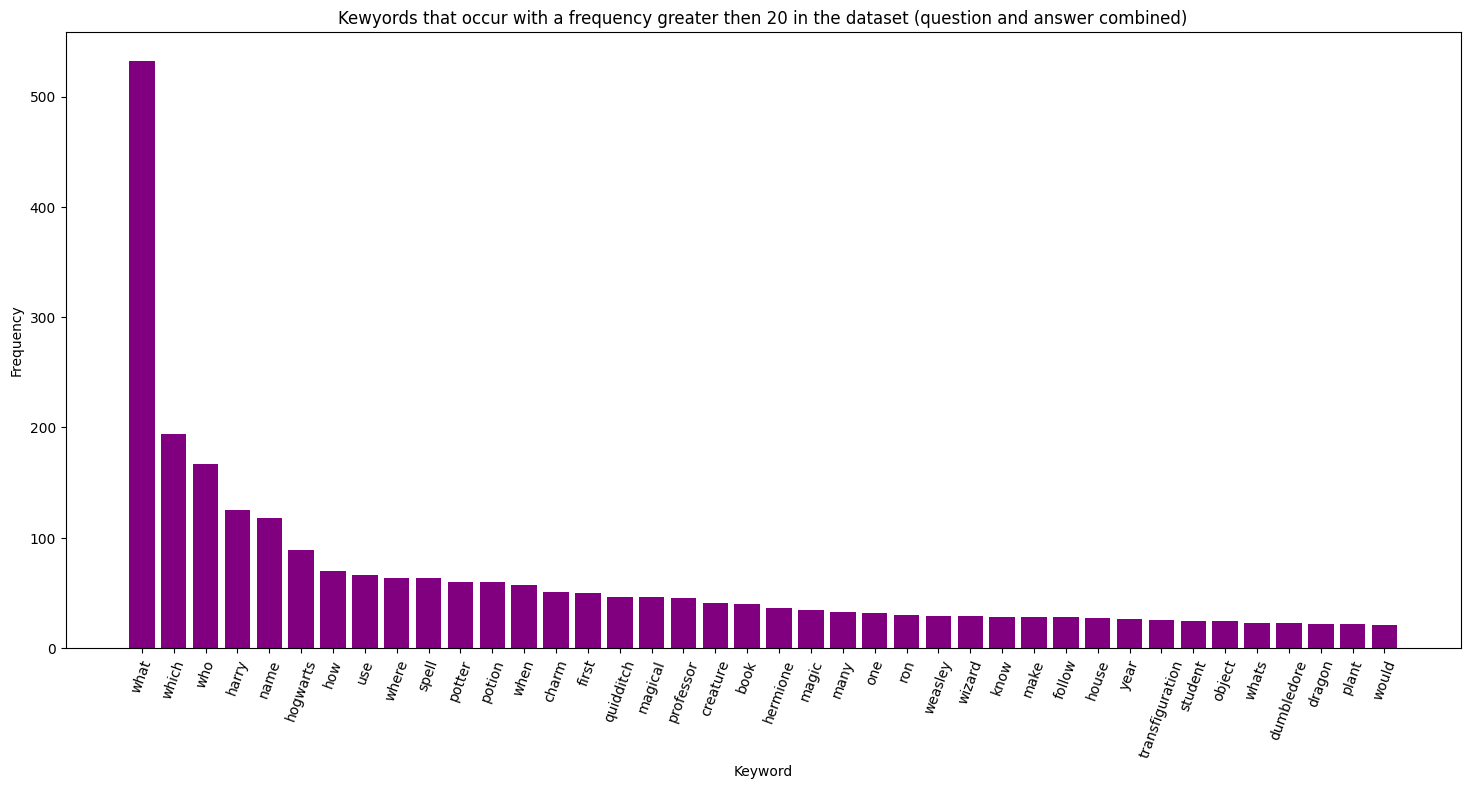

In [32]:
plt.figure(figsize=(18,8))

plt.bar(filtered_keyword_count_df['Keyword'], filtered_keyword_count_df['Frequency'], color="purple")

plt.xlabel('Keyword')
plt.ylabel('Frequency')
plt.title(f"Kewyords that occur with a frequency greater then {frequency_cutoff} in the dataset (question and answer combined)")
plt.xticks(rotation=70)
plt.show()

**Notes on keyword frequency**
1. The `what`, `which`, `who`, `name`, `how` and `where` are in top 10 of the frequency counts, so it looks like majority questions are likely to be factual types. These questions in all likelihood should have short answers. We can take a closer look at the dataset to confirm. `What` by far is the most common type of question keyword.
2. Its not a suprise that `harry` and `hogwarts` are also in the top - they would be the most common contextual keyword.
3. `spell` also might be a factual question? what kind of spell - may be check if all occurrence of spell are the factual question keywords? The same logic would be for `potion` and `charm`. 
4. There are some very wordy answers, it'll be interesting to look at their question format / type.
5. Note - `whats` and `would` also appear near the tail end of the graph although `would` questions could be quite open-ended?

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 7.2. Factual recall questions

In trivia, some of the most common questions are usually concerned with recalling specific facts to test the player. These questions typically ask about names, places, events, or spells. 

From the figure above, we can see that the top interrogative keywords like 'what', 'which', 'who', along with frequent subject-related keywords like 'harry' and 'name', dominate. This strongly suggests that many questions could be *factual recall* types. So, we can expect these questions to have typical formats such 'What is Albus Dumbledore's full name?" or "Where did Harry live during the summer holidays?".  We can assess the occurence of such typical keywords in the `question keywords` along with their frequency. These keywords could be:

- "Who...?" -> related to a character name.
- "What...?" -> an object, fact, event
- "Where...?" -> a location
- "When...?" / "In what year...?" -> would relate a timing of an event (books timeline)
- "How many...?" -> Number (although 'how' on its own can be open-ended. so might have to check for presence of both)
- "Name the..." -> a list / name(s)
<br>

**Methodology for analysis**:

First frequency of occurence of the "factual recall keywords" was determined based on a predefined list that was iteratively updated based on the analysis ([section 6.2.1](#621-Distribution-of-factual-recall-type-questions)). Then a more granular analysis was done by filtering and analysing questions for each question keyword ([section 6.2.2](#622-what-do-the-what-questions-look-like) to [section 6.2.5](#625-what-do-when-questions-look-like)).

A set of custom functions were developed to assess these keyword questions in a systematic, efficient, and standardized way. These functions are located in the `eda_scripts.py` module and imported into the notebook. The main steps for analyzing questions by 'factual recall' keywords (e.g. "what", "where") is to use the:

1. `eda.get_question_type_info(df_for_analysis,q_keyword, n_samples)` method to obtain summary analysis. This method uses the occurence of the keyword in the `question keyword` column to filter the relevant record. This includes:
    - the number (and percentage) of questions in the dataset with the selected "keyword" in it, 
    - the maximum, minimum, and descriptive statistics for the answer lengths associated with the question,
    - a sample of the filtered dataframe used by the method.
2. `eda.create_ans_len_boxplot(df_for_analysis,q_keyword)` method to generate side-by-side box plots of the filtered "keyword" questions and associated answers.
3.  `eda.print_keyword_ngrams(df_for_analysis['question'],keyword,(min_ngram_size, max_ngram_size))` to find n-grams in the raw question string in the `question` column, a custom list of stop words (default is None), and a range of n-gram size that are of iterest. By default the method looks at the top 10 but this parameter can also be changed. N-grams allow contextual understanding of the question, e.g. confirm it is a factual recall type? with stop words filtering it gives more information on the harry potter context and shows how the keywords are frequently chained together.

### Section 7.2 quick links

[7.2.1. Distribution of factual recall type questions](#721-Distribution-of-factual-recall-type-questions)<br>
[7.2.2. What do the "what" questions look like?](#722-What-do-the-what-questions-look-like)<br>
[7.2.3. What do the "who" questions look like? ](#723-What-do-the-who-questions-look-like)<br>
[7.2.4. What do the "where" questons look like?](#724-What-do-the-where-questions-look-like)<br>
[7.2.5. What do the "when" questions look like?](#725-what-do-when-questions-look-like)<br>

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

### 7.2.1. Distribution of factual recall type questions 

Now let's take a wider look at the dataset and see how many answers we can consider to be *factual recall* . We can create a list of words to look for. The list might not be exhaustive but will gives us a good sense of the dataset.

In [33]:
# list of words to look for when identifying 'factual recall' questions 
factual_recall_list = ['what', 'name', 'who', 'where', 'when', 'whats']

trivia_keywords_df = eda.tag_questions_by_keyword_list(
    df=trivia_keywords_df,
    keyword_column='question tokens', # Make sure this is the correct column name
    trigger_keyword_list=factual_recall_list,
    new_column_name='factual_recall_keyword'
)

In [34]:
# Sanity check
trivia_keywords_df.head()

,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
0,What are the three European wizarding schools that participate in the Triwizard Tournament?,"Hogwarts, Beauxbatons, and Durmstrang.","[what, three, european, wizarding, school, participate, triwizard, tournament]","[hogwarts, beauxbatons, durmstrang]","[what, three, european, wizarding, school, participate, triwizard, tournament, hogwarts, beauxbatons, durmstrang]",[what]
1,When was Hogwarts founded?,10th century,"[when, hogwarts, found]","[th, century]","[when, hogwarts, found, th, century]",[when]
2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, wronski, feint]","[pretend, dive, snitch]","[what, wronski, feint, pretend, dive, snitch]",[what]
3,You wouldn't know anything about this. Name a method to make your broom go faster.,Using polish,"[wouldnt, know, anything, name, method, make, broom, go, faster]","[use, polish]","[wouldnt, know, anything, name, method, make, broom, go, faster, use, polish]",[name]
4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[harry, first, take, knight, bus, prisoner, azkaban, how, much, ticket, cost, include, hot, chocolate]",[sickle],"[harry, first, take, knight, bus, prisoner, azkaban, how, much, ticket, cost, include, hot, chocolate, sickle]",N/A


The main analysis parameters going forward are defined here for ease of use and error management. This includes:
- `df_for_analysis`: The cleaned and processed copy of the dataset that is the same across the analysis but called multiple times in functions.
- `n_samples`: The number of random samples to display from the dataframe filtered by keyword (the methods have built-in corrections if the dataframe size is smaller then n_samples).

In [35]:
# Parameters for analysis:
df_for_analysis = trivia_keywords_df.copy()
n_samples = 5

In [36]:
## How many of the records have vs. don't have a 'N/A' tag for the 'factual_recall_keyword'?

# where 'factual_recall_keyword' is N/A
not_factual_q_count = trivia_keywords_df[trivia_keywords_df['factual_recall_keyword']=='N/A']['question'].count()
not_factual_q_percentage = (not_factual_q_count / trivia_keywords_df.shape[0]) * 100
# where 'factual_recall_keyword' is not N/A
factual_q_count = trivia_keywords_df.shape[0] - not_factual_q_count
factual_q_percentage = 100 - not_factual_q_percentage

# display results
print("Factual recall questions:\n",
      f"- There are at least {factual_q_count} questions ({factual_q_percentage: .0f}% of total count) that can be considered factual recall types.\n",
      f"- There are {not_factual_q_count} questions ({not_factual_q_percentage: .0f}% of total count) that can be considered as not being factual recall types."
)

Factual recall questions:
 - There are at least 802 questions ( 74% of total count) that can be considered factual recall types.
 - There are 283 questions ( 26% of total count) that can be considered as not being factual recall types.


In [37]:
## How are the factual questions distributed?

# 1. Create a dictionary to store values for easy plotting
factq_dict = {}
total = trivia_keywords_df.shape[0]

for keyword in factual_recall_list:
    # check if keyword contains a list and then if keyword is in the list:
    filter_condition = lambda x: keyword in x if isinstance(x, list) else False
    count = trivia_keywords_df[trivia_keywords_df['factual_recall_keyword'].apply(filter_condition)].shape[0]
    factq_dict[keyword] = {
        'count': count,
        'percentage of total': (count / total) * 100
    }


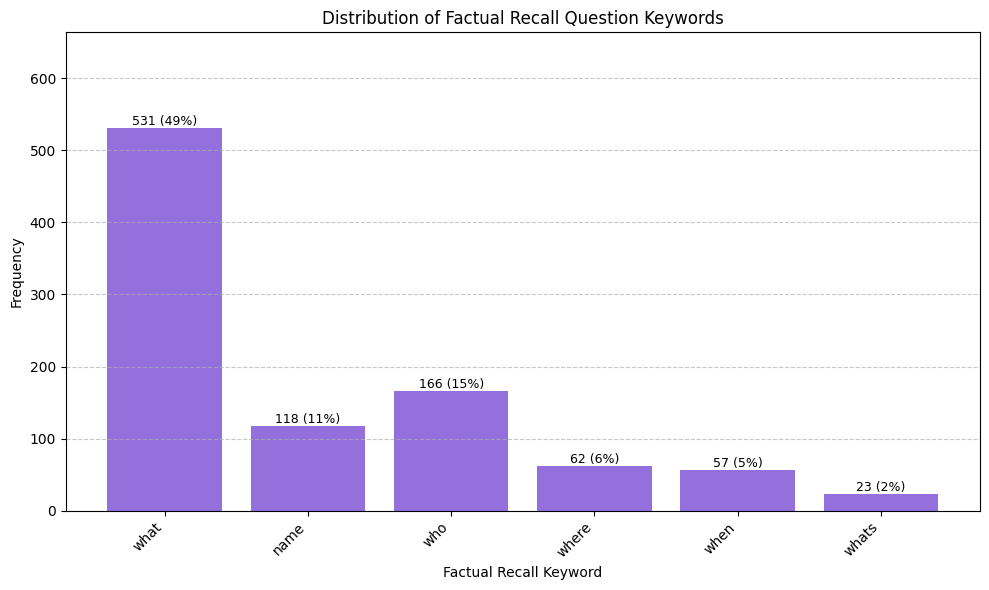

In [38]:
# 2. Visualize as a barchart 

factq_counts_series = pd.Series({k: v['count'] for k, v in factq_dict.items()})
total_questions = trivia_keywords_df.shape[0]

eda.plot_categorical_distribution(factq_counts_series, total_questions,
                              "Distribution of Factual Recall Question Keywords",
                              "Factual Recall Keyword")

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

### 7.2.2 What do the `"what"` questions look like?

Let's start by looking at "What" type questions as they are the most common (as per figure 3).

## Analysis for Keyword: 'WHAT'

Number of Questions: 531 (48.9% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,10.10,2.55
Median,9.00,2.00
Std Dev,4.61,2.37
Min,3.00,1.00
Max,30.00,22.00
Skew,1.46,3.54



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=0.076)
* Pearson's r = 0.076, P-value = 0.078

Scatter Plot with Regression Line:


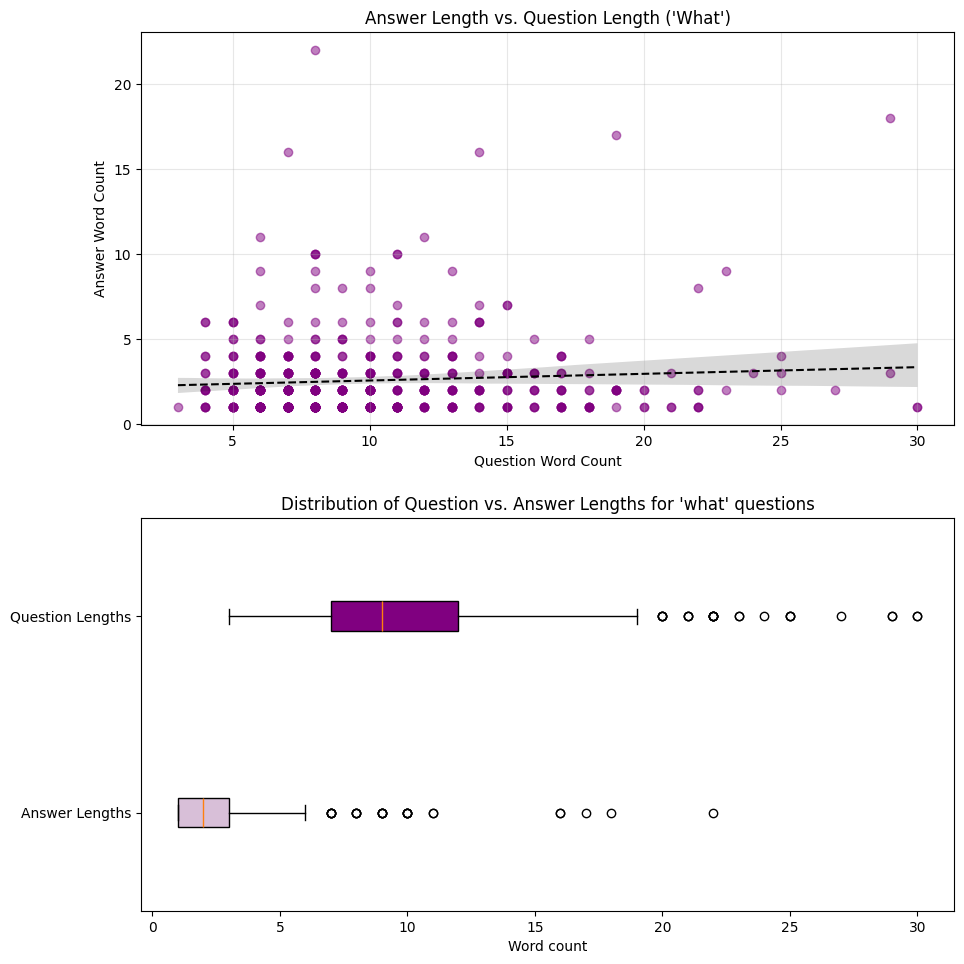


Random Sample (5) of 'what' Questions:


,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
431,Colovaria is also known as what?,Colour Change Charm,"[colovaria, also, know, what]","[colour, change, charm]","[colovaria, also, know, what, colour, change, charm]",[what]
274,"In 1997, what was written on the statue at the Ministry of Magic under Voldemort's control?",Magic is Might,"[what, write, statue, ministry, magic, voldemorts, control]","[magic, might]","[what, write, statue, ministry, magic, voldemorts, control, might]",[what]
683,What is Gilderoy Lockhart’s autobiography called?,Magical Me,"[what, gilderoy, lockharts, autobiography, call]",[magical],"[what, gilderoy, lockharts, autobiography, call, magical]",[what]
251,What Goblin led the 18th century Golbin Rebellions?,Urg the Unclean,"[what, goblin, lead, th, century, golbin, rebellion]","[urg, unclean]","[what, goblin, lead, th, century, golbin, rebellion, urg, unclean]",[what]
136,What is the antidote to Swelling Solution?,Deflating Draught,"[what, antidote, swell, solution]","[deflate, draught]","[what, antidote, swell, solution, deflate, draught]",[what]


----------------------------------------------------------------------


In [39]:
q_keyword = "what"
what_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(what_q_metrics, n_samples)

Ok, there is quite a range in answer length and we can't make any generalization about them. 

In [40]:
eda.print_keyword_ngrams(df_for_analysis['question'],'what',(2,5))


Analyzing common phrases (n-grams) starting with 'what' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'what':
- 'what is': 174
- 'what is the': 111
- 'what does': 50
- 'what is the name': 46
- 'what is the name of': 46
- 'what was': 27
- 'what did': 24
- 'what does the': 21
- 'what was the': 18
- 'what are': 17


In [41]:
# let's remove 'is', 'the', 'are', 'was' as our custom stop word list:
stop_words = ['is', 'the', 'are', 'was', 'does', 'did', 'do', 'kind', 'of', 'for','type'] 
eda.print_keyword_ngrams(df_for_analysis['question'],'what',(2,5), 10, stop_words)


Analyzing common phrases (n-grams) starting with 'what' in this set of questions:
Using stop_words: ['is', 'the', 'are', 'was', 'does', 'did', 'do', 'kind', 'of', 'for', 'type']
Top 10 common n-grams starting with 'what':
- 'what name': 63
- 'what spell': 17
- 'what magical': 16
- 'what creature': 15
- 'what incantation': 13
- 'what harry': 10
- 'what potion': 9
- 'what magical creature': 8
- 'what animal': 6
- 'what charm': 6


These N-grams also indicate that the "what" questions are asking for factual details.

Now let's also look at `name` keyword, it is the second-most frequent keyword but there might be an overlap with the `what` questions.

In [42]:
## What do questions with the 'name' keyword look like?

# Filter question that the word 'name' in them
name_questions = df_for_analysis.loc[df_for_analysis['question tokens'].apply(lambda x: keyword in x)]

# Now filter that subset of question to find the occurence of "name" without "what" / "what's" present.
name_nowhat_questions = name_questions[
    ~name_questions['question tokens'].apply(lambda x: 'what' in x or 'whats' in x)
]
# display results
print("Occurence of 'name' without 'what' in the trivia questions: ",name_nowhat_questions.shape[0])

Occurence of 'name' without 'what' in the trivia questions:  0


It look like that in this dataset "name" always appears with "what". So we don't have to consider them separately for now. However, it is entirely possible to phrase the question with just "name", e.g. "Name the characters from ....." and can be possible when the dataset is expanded.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

### 7.2.3. What do the `"who"` questions look like?

Let's start by looking at "What" type questions as they are the most common (as per figure 3).

## Analysis for Keyword: 'WHO'

Number of Questions: 166 (15.3% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,9.57,2.52
Median,8.00,2.00
Std Dev,4.73,1.86
Min,3.00,1.00
Max,31.00,11.00
Skew,1.71,3.25



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=0.104)
* Pearson's r = 0.104, P-value = 0.184

Scatter Plot with Regression Line:


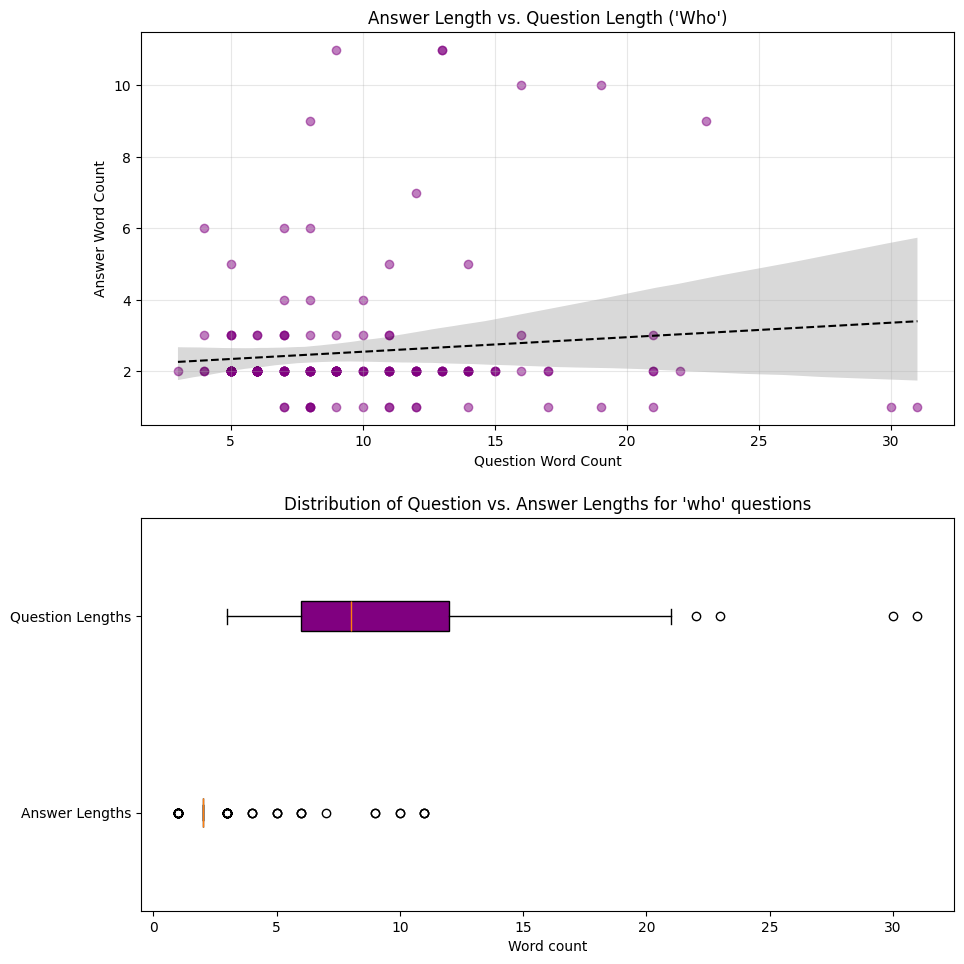


Random Sample (5) of 'who' Questions:


,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
78,"In the Order of Phoenix, who gives the flying lessons to Harry's group?",Rolanda Hooch,"[order, phoenix, who, give, fly, lesson, harrys, group]","[rolanda, hooch]","[order, phoenix, who, give, fly, lesson, harrys, group, rolanda, hooch]",[who]
343,Who is the Divination Professor?,Professor Trelawney,"[who, divination, professor]","[professor, trelawney]","[who, divination, professor, trelawney]",[who]
32,Who was the first Quidditch referee to die in a Quidditch match?,Cyprian Youdle,"[who, first, quidditch, referee, die, match]","[cyprian, youdle]","[who, first, quidditch, referee, die, match, cyprian, youdle]",[who]
691,Who wrote the Dream Oracle?,Inigo Imago,"[who, write, dream, oracle]","[inigo, imago]","[who, write, dream, oracle, inigo, imago]",[who]
530,What potion gives good luck to those who drink it?,Felix Felicis,"[what, potion, give, good, luck, who, drink]","[felix, felicis]","[what, potion, give, good, luck, who, drink, felix, felicis]","[what, who]"


----------------------------------------------------------------------


In [43]:
q_keyword = "who"
who_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(who_q_metrics, n_samples)

**Note**: Although we know there is considerable overlap between 'what' and 'name' - 'name' remains in assessment for completeness.

In [44]:
# With no stop_words considered:
eda.print_keyword_ngrams(df_for_analysis['question'],"who", (2,5))


Analyzing common phrases (n-grams) starting with 'who' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'who':
- 'who is': 56
- 'who is the': 38
- 'who was': 20
- 'who was the': 12
- 'who wrote': 8
- 'who does': 7
- 'who invented': 5
- 'who is harry': 4
- 'who teaches': 4
- 'who created': 3


In [45]:
# Using a custom list of stop words.
stop_words = ['is', 'was', 'does', 'the', 'of', 'in']
eda.print_keyword_ngrams(df_for_analysis['question'],"who", (3,7), stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'who' in this set of questions:
Using stop_words: ['is', 'was', 'does', 'the', 'of', 'in']
Top 10 common n-grams starting with 'who':
- 'who headmaster hogwarts': 6
- 'who harry potter': 3
- 'who harry potter godfather': 3
- 'who original owner': 3
- 'who created sorcerer': 2
- 'who created sorcerer stone': 2
- 'who destroyed horcrux': 2
- 'who destroyed horcrux helga': 2
- 'who divination professor': 2
- 'who flying instructor': 2


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

### 7.2.4. What do the "where" questions look like? 

## Analysis for Keyword: 'WHERE'

Number of Questions: 62 (5.7% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,9.45,3.18
Median,9.00,3.00
Std Dev,3.99,2.40
Min,4.00,1.00
Max,22.00,14.00
Skew,0.96,2.61



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=0.236)
* Pearson's r = 0.236, P-value = 0.064

Scatter Plot with Regression Line:


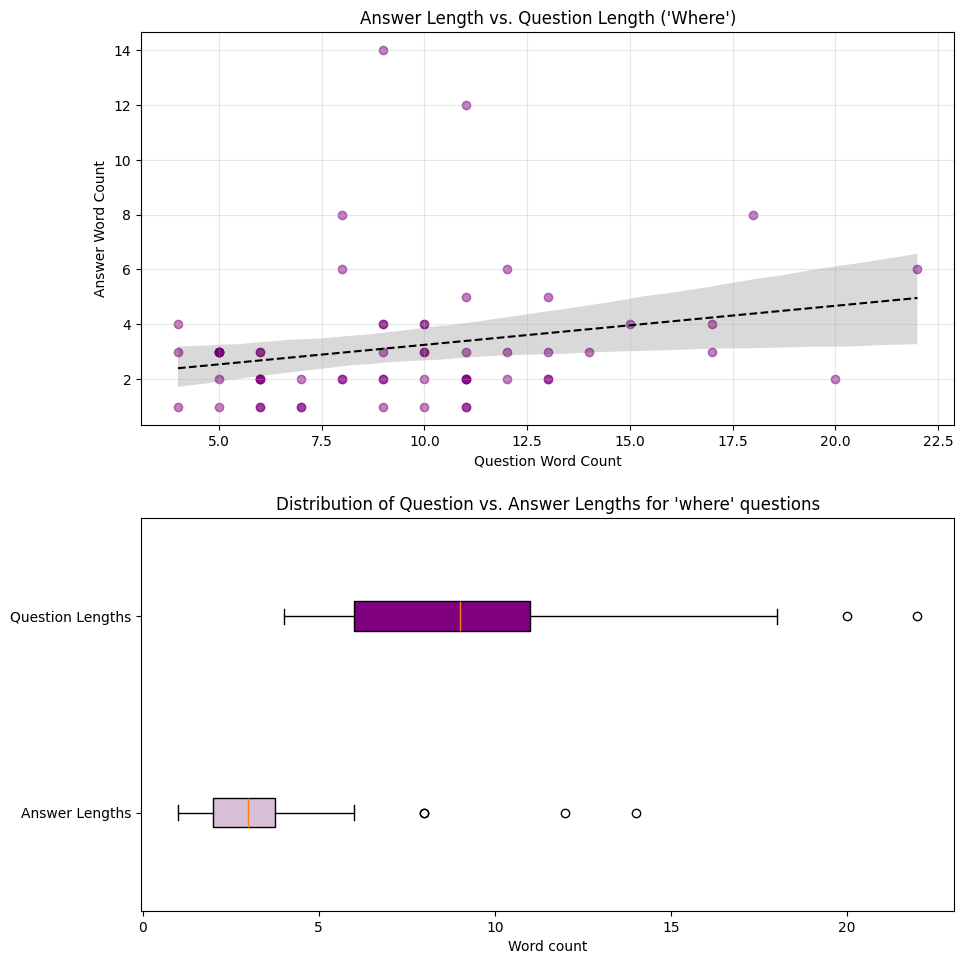


Random Sample (5) of 'where' Questions:


,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
151,Where does Harry Potter first see Draco Malfoy?,In Madame Malkin’s Robes for All Occasions,"[where, harry, potter, first, see, draco, malfoy]","[madame, malkins, robes, occasion]","[where, harry, potter, first, see, draco, malfoy, madame, malkins, robes, occasion]",[where]
611,"In the Chamber of Secrets, where does Harry discover the entrance to the Chamber?",Myrtle's bathroom,"[chamber, secret, where, harry, discover, entrance]","[myrtle, bathroom]","[chamber, secret, where, harry, discover, entrance, myrtle, bathroom]",[where]
303,Where can Knotgrass be found?,The Forbidden Forest,"[where, knotgrass, find]","[forbidden, forest]","[where, knotgrass, find, forbidden, forest]",[where]
449,"In Harry Potter and the Chamber of Secrets, where were Harry, Hermione, and Ron coming from when they found Mrs. Norris petrified?",Nearly Headless Nick's Deathday Party,"[harry, potter, chamber, secret, where, hermione, ron, come, when, find, mrs, norris, petrify]","[nearly, headless, nick, deathday, party]","[harry, potter, chamber, secret, where, hermione, ron, come, when, find, mrs, norris, petrify, nearly, headless, nick, deathday, party]","[where, when]"
878,Where is the best place to buy flesh-eating repellent?,Knockturn Alley,"[where, best, place, buy, flesheating, repellent]","[knockturn, alley]","[where, best, place, buy, flesheating, repellent, knockturn, alley]",[where]


----------------------------------------------------------------------


In [46]:
q_keyword = "where"
where_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(where_q_metrics, n_samples)

In [47]:
eda.print_keyword_ngrams(df_for_analysis['question'], "where")


Analyzing common phrases (n-grams) starting with 'where' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'where':
- 'where is': 14
- 'where is the': 12
- 'where did': 9
- 'where do': 8
- 'where does': 8
- 'where was': 5
- 'where are': 4
- 'where can': 3
- 'where was harry': 3
- 'where are the': 2


In [48]:
# Using a custom list of stop words.
stop_words = ['is', 'did', 'do', 'does', 'was', 'are', 'can', 'the', 'to']
eda.print_keyword_ngrams(df_for_analysis['question'], "where",stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'where' in this set of questions:
Using stop_words: ['is', 'did', 'do', 'does', 'was', 'are', 'can', 'the', 'to']
Top 10 common n-grams starting with 'where':
- 'where harry': 8
- 'where harry potter': 5
- 'where entrance': 4
- 'where entrance chamber': 3
- 'where best': 2
- 'where best place': 2
- 'where dumbledore': 2
- 'where find': 2
- 'where find them': 2
- 'where first': 2


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

### 7.2.5. What do "when" questions look like?

## Analysis for Keyword: 'WHEN'

Number of Questions: 57 (5.3% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,11.96,2.82
Median,11.00,2.00
Std Dev,6.15,2.52
Min,4.00,1.00
Max,27.00,13.00
Skew,0.74,2.19



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=0.092)
* Pearson's r = 0.092, P-value = 0.498

Scatter Plot with Regression Line:


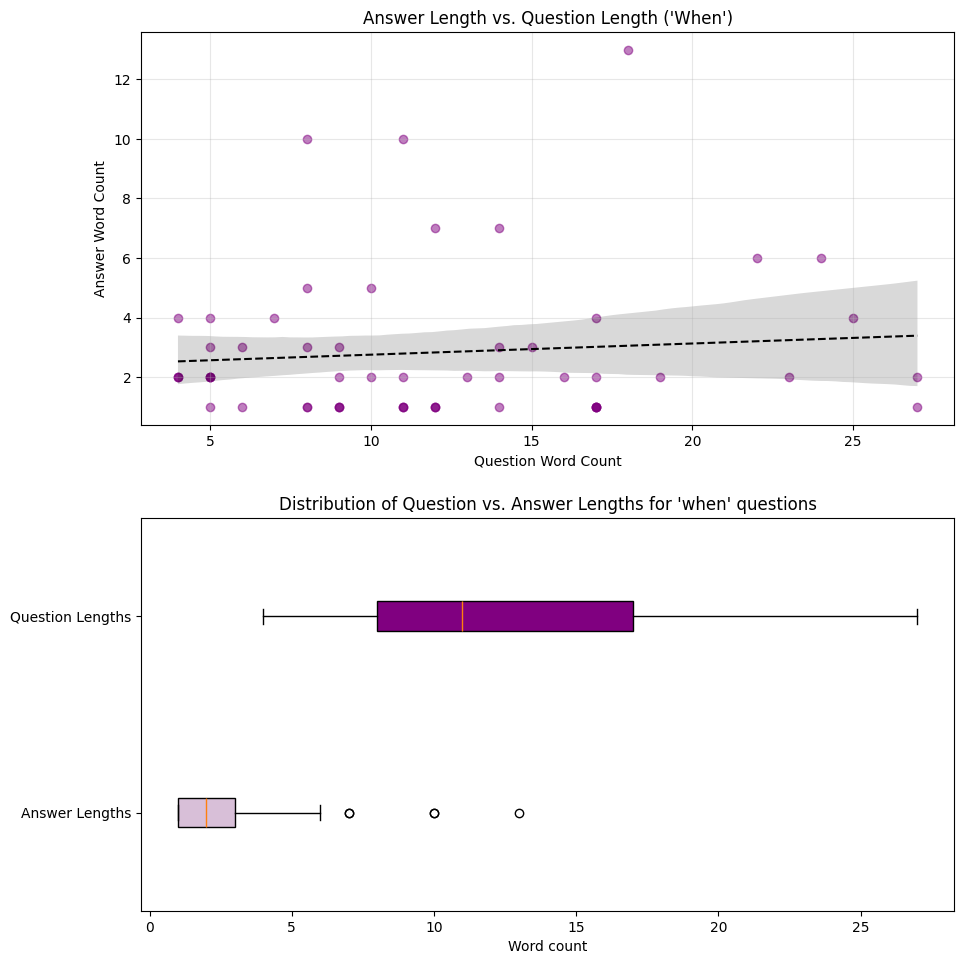


Random Sample (5) of 'when' Questions:


,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
657,When was He Who Must Not Be Named defeated?,Halloween,"[when, who, must, name, defeat]",[halloween],"[when, who, must, name, defeat, halloween]","[name, who, when]"
1041,When was the first full description of the game of Quidditch written?,1398,"[when, first, full, description, game, quidditch, write]",[],"[when, first, full, description, game, quidditch, write]",[when]
195,Who was headmaster or headmistress at Hogwarts when Tom Riddle was a student?,Armando Dippet,"[who, headmaster, headmistress, hogwarts, when, tom, riddle, student]","[armando, dippet]","[who, headmaster, headmistress, hogwarts, when, tom, riddle, student, armando, dippet]","[who, when]"
426,What does it mean when a magical creature is classified as X by the Ministry of Magic?,Boring,"[what, mean, when, magical, creature, classify, ministry, magic]",[boring],"[what, mean, when, magical, creature, classify, ministry, magic, boring]","[what, when]"
736,When was Quidditch invented?,1050 AD,"[when, quidditch, invent]",[ad],"[when, quidditch, invent, ad]",[when]


----------------------------------------------------------------------


In [49]:
q_keyword = "when"
when_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(when_q_metrics, n_samples)

In [50]:
eda.print_keyword_ngrams(df_for_analysis['question'], "when")


Analyzing common phrases (n-grams) starting with 'when' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'when':
- 'when was': 10
- 'when he': 7
- 'when did': 6
- 'when harry': 6
- 'when is': 3
- 'when was the': 3
- 'when did the': 2
- 'when harry arrives': 2
- 'when he decided': 2
- 'when is harry': 2


In [51]:
# Using a custom list of stop words.
stop_words = ['was', 'he', 'did', 'is', 'the', 'it', 'got', 'they']
eda.print_keyword_ngrams(df_for_analysis['question'], "when",stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'when' in this set of questions:
Using stop_words: ['was', 'he', 'did', 'is', 'the', 'it', 'got', 'they']
Top 10 common n-grams starting with 'when':
- 'when harry': 9
- 'when decided': 2
- 'when decided to': 2
- 'when first': 2
- 'when harry arrives': 2
- 'when harry birthday': 2
- 'when magical': 2
- 'when magical creature': 2
- 'when neville': 2
- 'when added': 1


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

## 7.3 Questions that do not have factual recall keywords

The 'factual recall keywords' is not exhaustive. So looking at the questions with an 'N/A' tag can help us:
1. Determine if any other keywords should be added to the list added to the list that we might not have caught this time.
2. Is there a pattern in the remaining questions? what kind of questions are they? 
3. Are these open-ended type questions? e.g."Why....?" or "Would...?"

We can start looking at the tokens specific to this subset of the data frame and how frequently they occur.

#### Section 7.3 quick links

[7.3.1. What do the "which" questions look like?](#731-what-do-the-which-questions-look-like)<br>
[7.3.2. What do the "who" questions look like?](#732-what-do-the-why-questions-look-like)<br>
[7.3.3. What do the "how" questions look like?](#733-what-do-the-how-type-questions-look-like)<br>
[7.3.4. How many questions contain multiple keywords? ](#734-how-many-questions-contain-multiple-keywords)<br>
[7.3.5. What do the remaining "N/A" questions look like? ](#735-what-do-the-remaining-na-questions-look-like)<br>
[7.3.6. Plan of action ](#736-plan-of-action)

In [52]:
# What are the common tokens in the N/A tagged questions?

# A. Filter the relevant questions where the 'factual_recall_keyword' is 'N/A'
q_filtered_df = trivia_keywords_df[trivia_keywords_df['factual_recall_keyword']=='N/A']
q_filtered_df.sample(10)

,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
812,This real-life library served as the restricted section of the Hogwarts library in the film version. Which is it?,The Bodleian Library at Oxford University,"[reallife, library, serve, restricted, section, hogwarts, film, version, which]","[bodleian, library, oxford, university]","[reallife, library, serve, restricted, section, hogwarts, film, version, which, bodleian, oxford, university]",N/A
502,Which book is instrumental for this lesson?,Charm Your Own Cheese.,"[which, book, instrumental, lesson]","[charm, cheese]","[which, book, instrumental, lesson, charm, cheese]",N/A
1047,Which of these words best describes Slytherin House?,Resourceful,"[which, word, best, describes, slytherin, house]",[resourceful],"[which, word, best, describes, slytherin, house, resourceful]",N/A
227,The three D's of Apparition do not include which of the below?,Dimension,"[three, ds, apparition, include, which]",[dimension],"[three, ds, apparition, include, which, dimension]",N/A
367,Which dark magic item is known as the friend of thieves?,Hand of Glory,"[which, dark, magic, item, know, friend, thief]","[hand, glory]","[which, dark, magic, item, know, friend, thief, hand, glory]",N/A
108,The Deflating Drought is an antidote to which potion?,Swelling Solution,"[deflate, drought, antidote, which, potion]","[swell, solution]","[deflate, drought, antidote, which, potion, swell, solution]",N/A
826,Which elective is occasionally offered at Hogwarts?,Alchemy,"[which, elective, occasionally, offer, hogwarts]",[alchemy],"[which, elective, occasionally, offer, hogwarts, alchemy]",N/A
9,Why did student initially think Harry was the Heir of Slytherin?,He can speak Parseltongue,"[why, student, initially, think, harry, heir, slytherin]","[speak, parseltongue]","[why, student, initially, think, harry, heir, slytherin, speak, parseltongue]",N/A
986,An Infusion of Wormwood is NOT an ingredient in which of these potions?,Beautification Potion,"[infusion, wormwood, ingredient, which, potion]","[beautification, potion]","[infusion, wormwood, ingredient, which, potion, beautification]",N/A
817,How was Hermione able to take extra lessons?,She used a time-turner,"[how, hermione, able, take, extra, lesson]","[use, timeturner]","[how, hermione, able, take, extra, lesson, use, timeturner]",N/A


In [53]:
# B. Count the occurence of each question token

# 1. create a copy so original df is not modified.
na_frq_df = q_filtered_df[['question', 'question tokens']].copy()

# 2. Use  the explode method to expand the list into individual column entries:
na_q_df = na_frq_df.explode('question tokens')

# 3. Now we can count values of the each token occurence in the `question tokens` column:
na_q_counts = na_q_df['question tokens'].value_counts()

# 3. print results
# Rename the index and values columns for clarity:
na_q_counts.index.name = "keyword"
na_q_counts.name = "Frequency"
total_na_q = q_filtered_df.shape[0]

print(f'* There are a total of {total_na_q} questions that are tagged as "N/A" in the "factual_recall_keywords" column.\n')
print("* Summary of the 'N/A' question keyword tokens (cutoff to display only with counts > 10): \n")
print(na_q_counts[na_q_counts>10])

# print percentage of 'which' and 'why' keywords:
which_q_percent_of_na = (na_q_counts['which'] / total_na_q) * 100
why_q_percent_of_na =  (na_q_counts['why'] / total_na_q) * 100

print(f"\n* Percentage of 'which' questions in the 'N/A' filtered dataset: {which_q_percent_of_na: .1f}%")
print(f"* Percentage of 'why' questions in the 'N/A' filtered dataset: {why_q_percent_of_na: .1f}%")

* There are a total of 283 questions that are tagged as "N/A" in the "factual_recall_keywords" column.

* Summary of the 'N/A' question keyword tokens (cutoff to display only with counts > 10): 

keyword
which        188
how           61
many          30
use           25
spell         25
follow        23
hogwarts      22
harry         22
quidditch     21
potion        21
charm         15
would         14
why           12
one           12
plant         11
first         11
Name: Frequency, dtype: int64

* Percentage of 'which' questions in the 'N/A' filtered dataset:  66.4%
* Percentage of 'why' questions in the 'N/A' filtered dataset:  4.2%


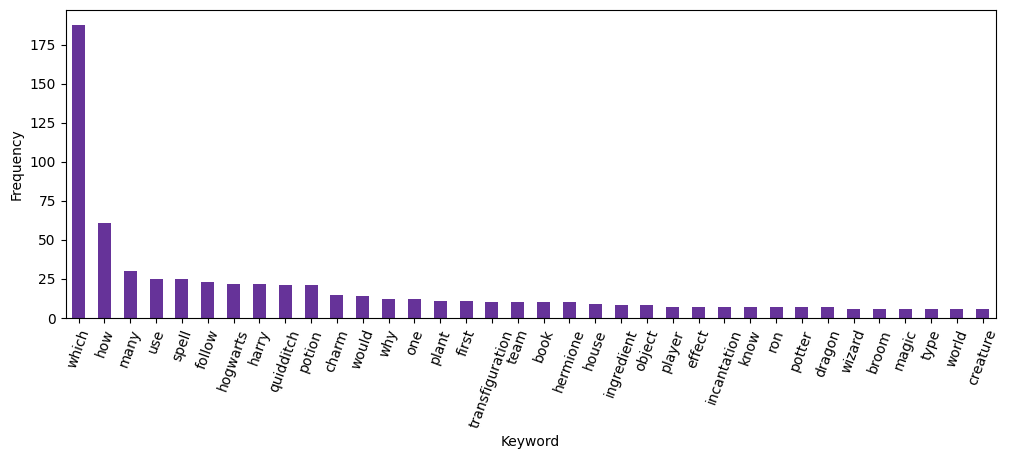

In [54]:
# Filter for values greater than a threshold so the chart isn't cluttered by the tail
threshold = 5
high_frequency_tokens = na_q_counts[na_q_counts > threshold]

high_frequency_tokens.plot(kind='bar', figsize=(12,4), color='rebeccapurple')
plt.xlabel('Keyword')
plt.ylabel('Frequency')
# plt.title(f"Figure {figure_count}. Kewyords that occur with a frequency greater then {frequency_cutoff} in the dataset (question and answer combined)")
plt.xticks(rotation=70)
plt.show()

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

### 7.3.1. What do the "which" questions look like?

## Analysis for Keyword: 'WHICH'

Number of Questions: 194 (17.9% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,10.22,2.14
Median,9.00,2.00
Std Dev,3.74,1.50
Min,4.00,1.00
Max,24.00,9.00
Skew,1.51,2.17



Correlation between Question and Answer Length:
* Interpretation: Statistically significant (correlation is Very Weak)
* Pearson's r = 0.150, P-value = 0.036

Scatter Plot with Regression Line:


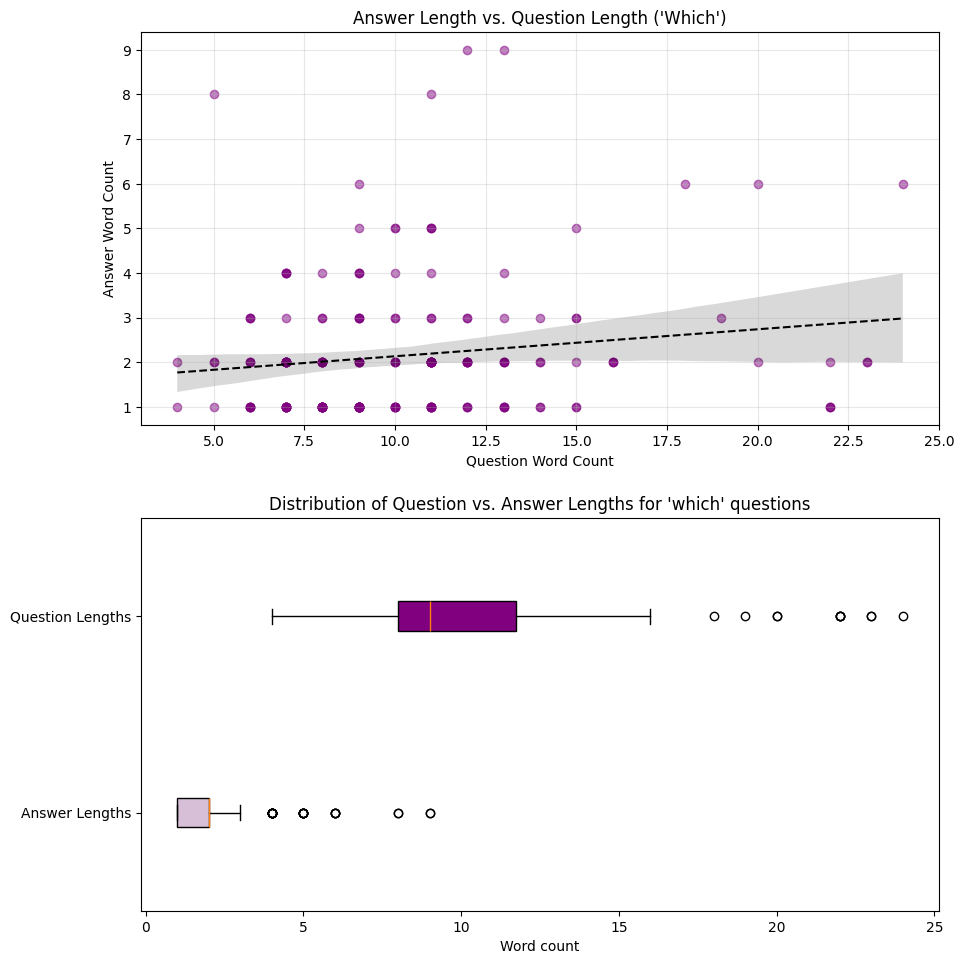


Random Sample (5) of 'which' Questions:


,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
975,Which spell would you use to tame Devil's Snare?,Incendio,"[which, spell, would, use, tame, devil, snare]",[incendio],"[which, spell, would, use, tame, devil, snare, incendio]",N/A
257,Which character do we see ride a broom for the first time in this movie?,Hermione Granger,"[which, character, see, ride, broom, first, time, movie]","[hermione, granger]","[which, character, see, ride, broom, first, time, movie, hermione, granger]",N/A
159,Which of the following traits does the Occamy exhibit?,Choranaptyxis,"[which, follow, trait, occamy, exhibit]",[choranaptyxis],"[which, follow, trait, occamy, exhibit, choranaptyxis]",N/A
567,Which of these tasks can not be aided by a Vanishing Spell?,Dancing,"[which, task, aid, vanish, spell]",[dance],"[which, task, aid, vanish, spell, dance]",N/A
1034,Which of these is not a type of concealment charm?,Confundus Charm,"[which, type, concealment, charm]","[confundus, charm]","[which, type, concealment, charm, confundus]",N/A


----------------------------------------------------------------------


In [55]:
q_keyword = "which"
which_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(which_q_metrics, n_samples)

In [56]:
eda.print_keyword_ngrams(df_for_analysis['question'],'which',(2,4))


Analyzing common phrases (n-grams) starting with 'which' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'which':
- 'which of': 65
- 'which of these': 38
- 'which of the': 25
- 'which of the following': 22
- 'which of these is': 11
- 'which is': 10
- 'which of these spells': 8
- 'which potion': 7
- 'which spell': 7
- 'which incantation': 6


In [57]:
eda.print_keyword_ngrams(df_for_analysis['question'],"which",(5,10))


Analyzing common phrases (n-grams) starting with 'which' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'which':
- 'which of the following is': 8
- 'which of these is not': 6
- 'which of the following is not': 5
- 'which of these spells is': 4
- 'which of these is an': 3
- 'which of these is not type': 3
- 'which of these is not type of': 3
- 'which of these scenarios would': 3
- 'which of these scenarios would you': 3
- 'which of these scenarios would you use': 3


**Observations: "Which" type questions**

- Marjority of the 'N/A' tagged questions are `which` type questions (194 questions). 
- In general we can expect `which` questions to be open-ended questions, but a closer look at these questions in the dataset confirms that they are also another form of a `factual recall question`.
- This in turn means that, with the inclusion of `which` into the keyword list, the vast majority of the questions (97%) can be considered as 'factual recall type questions' within this dataset.
- The longest answer is a list of characters full names.
- The sampled question generally seem to be difficult.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

### 7.3.2. What do the "why" questions look like?

## Analysis for Keyword: 'WHY'

Number of Questions: 12 (1.1% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,9.33,5.67
Median,8.50,4.00
Std Dev,2.84,4.19
Min,5.00,2.00
Max,15.00,14.00
Skew,0.88,1.36



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=-0.059)
* Pearson's r = -0.059, P-value = 0.856

Scatter Plot with Regression Line:


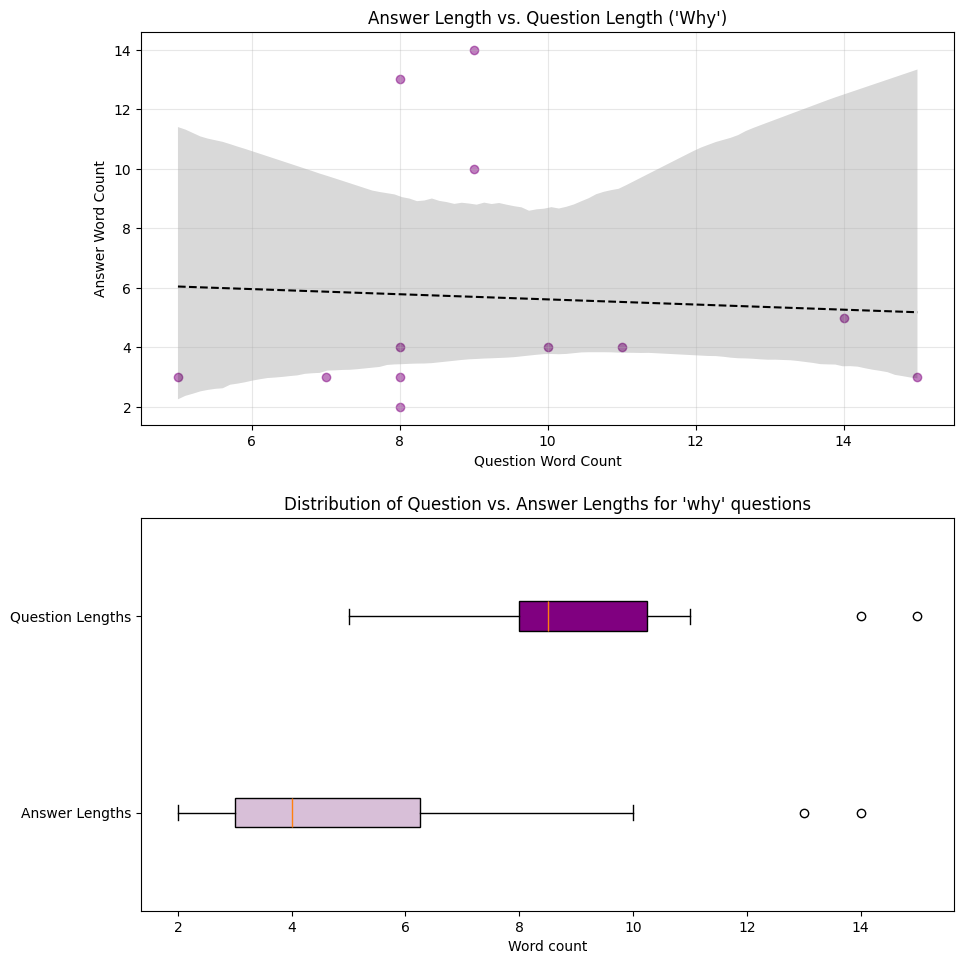


Random Sample (5) of 'why' Questions:


,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
9,Why did student initially think Harry was the Heir of Slytherin?,He can speak Parseltongue,"[why, student, initially, think, harry, heir, slytherin]","[speak, parseltongue]","[why, student, initially, think, harry, heir, slytherin, speak, parseltongue]",N/A
117,Why would you need to switch brooms midair?,Broom failure,"[why, would, need, switch, broom, midair]","[broom, failure]","[why, would, need, switch, broom, midair, failure]",N/A
105,Which of the following was a reason why the 14th century witch burnings were pointless?,Flame-Freezing Charm,"[which, follow, reason, why, th, century, witch, burning, pointless]","[flamefreezing, charm]","[which, follow, reason, why, th, century, witch, burning, pointless, flamefreezing, charm]",N/A
1045,Why did the Werewolf Code of Conduct fail?,No werewolves signed it.,"[why, werewolf, code, conduct, fail]","[werewolf, sign]","[why, werewolf, code, conduct, fail, sign]",N/A
960,Why did Hermione miss the lesson on Cheering Charms?,Draco's cruel behavior led her to miss the class.,"[why, hermione, miss, lesson, cheer, charm]","[draco, cruel, behavior, lead, miss, class]","[why, hermione, miss, lesson, cheer, charm, draco, cruel, behavior, lead, class]",N/A


----------------------------------------------------------------------


In [58]:
q_keyword = "why"
why_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(why_q_metrics, n_samples)

In [59]:
eda.print_keyword_ngrams(df_for_analysis['question'],'why', (2,4),5)


Analyzing common phrases (n-grams) starting with 'why' in this set of questions:
Using stop_words: None
Top 5 common n-grams starting with 'why':
- 'why did': 6
- 'why did the': 2
- 'why did the werewolf': 2
- 'why would': 2
- 'why would you': 2


In [60]:
stop_words = ['did', 'the', 'would' ,'do', 'does']
eda.print_keyword_ngrams(df_for_analysis['question'],'why',(2,3), 3, stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'why' in this set of questions:
Using stop_words: ['did', 'the', 'would', 'do', 'does']
Top 3 common n-grams starting with 'why':
- 'why werewolf': 2
- 'why werewolf code': 2
- 'why you': 2


**Observations:"why" type questions**
- From the token count we know that there are 12 `why` type questions in the filtered dataset and the full dataset (1% of the total).
- The answers to these questions are generally long, ranging between 13 to 87 words in general.
- These questions seem more open-ended with answers that can vary for players and would require interpretation.

[[Back to TOC]](#table-of-contents)

### 7.3.3. What do the "how" type questions look like?

## Analysis for Keyword: 'HOW'

Number of Questions: 70 (6.5% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,10.47,3.41
Median,9.00,2.00
Std Dev,4.67,4.70
Min,4.00,1.00
Max,27.00,25.00
Skew,1.30,3.14



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=0.049)
* Pearson's r = 0.049, P-value = 0.687

Scatter Plot with Regression Line:


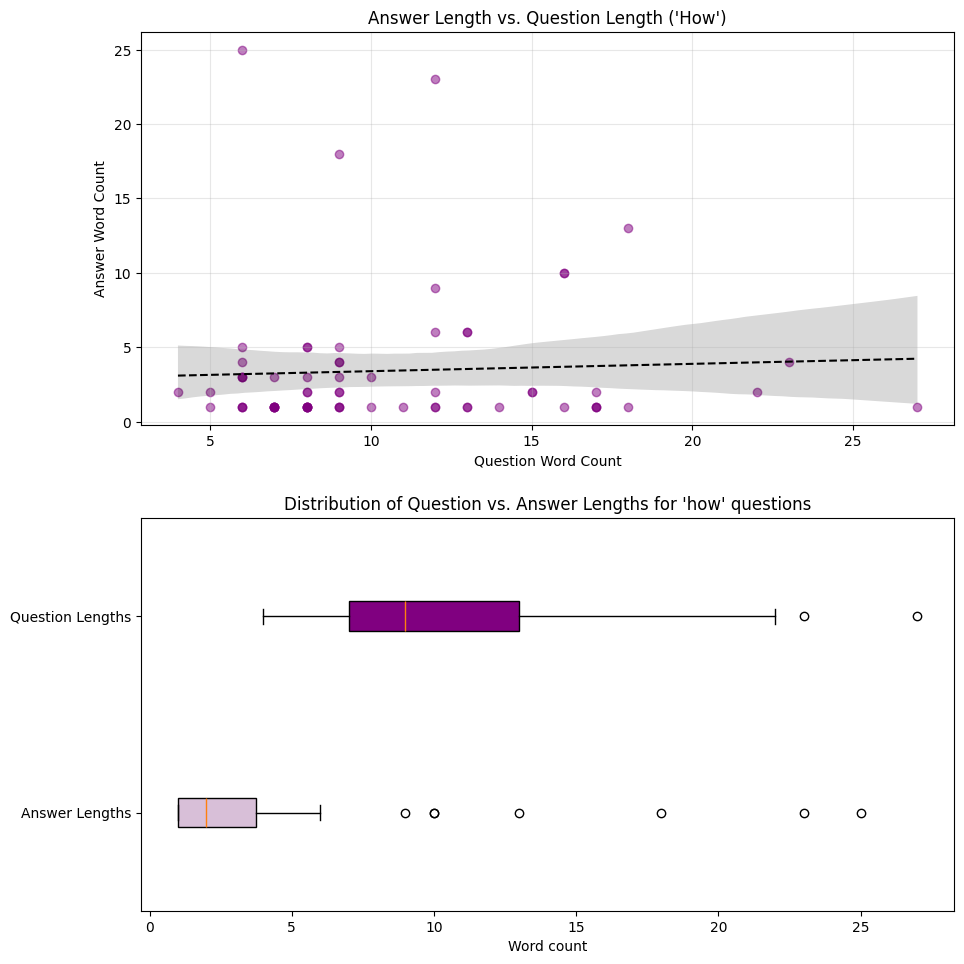


Random Sample (5) of 'how' Questions:


,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
629,How is Bellatrix related to Tonks?,Tonks is Bellatrix's niece.,"[how, bellatrix, related, tonks]","[tonks, bellatrixs, niece]","[how, bellatrix, related, tonks, bellatrixs, niece]",N/A
521,How many Muggles see the flying Ford Anglia as Harry and Ron make their way to school?,Seven,"[how, many, muggles, see, fly, ford, anglia, harry, ron, make, way, school]",[seven],"[how, many, muggles, see, fly, ford, anglia, harry, ron, make, way, school, seven]",N/A
389,How long was You-Know-Who in power?,11 Years,"[how, long, youknowwho, power]",[year],"[how, long, youknowwho, power, year]",N/A
283,Who did Harry overhear in the Three Broomsticks talking about how Sirius Black betrayed his parents?,"Professor Flitwick, Professor McGonagall, Hagrid, Cornelius Fudge and Madam Rosmerta","[who, harry, overhear, three, broomstick, talk, how, sirius, black, betrayed, parent]","[professor, flitwick, mcgonagall, hagrid, cornelius, fudge, madam, rosmerta]","[who, harry, overhear, three, broomstick, talk, how, sirius, black, betrayed, parent, professor, flitwick, mcgonagall, hagrid, cornelius, fudge, madam, rosmerta]",[who]
267,How many times did Wendelin the Weird allow herself to be caught?,Forty-seven.,"[how, many, time, wendelin, weird, allow, catch]",[fortyseven],"[how, many, time, wendelin, weird, allow, catch, fortyseven]",N/A


----------------------------------------------------------------------


In [61]:
q_keyword = "how"
how_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(how_q_metrics, n_samples)

In [62]:
eda.print_keyword_ngrams(df_for_analysis['question'],'how',(2,4))


Analyzing common phrases (n-grams) starting with 'how' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'how':
- 'how many': 31
- 'how do': 7
- 'how old': 6
- 'how does': 5
- 'how is': 5
- 'how did': 4
- 'how many times': 4
- 'how old was': 4
- 'how do you': 3
- 'how long': 3


In [63]:
stop_words = ['is', 'do', 'does', 'did', 'was', 'do']
eda.print_keyword_ngrams(df_for_analysis['question'],'how',(2,4), 5, stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'how' in this set of questions:
Using stop_words: ['is', 'do', 'does', 'did', 'was', 'do']
Top 5 common n-grams starting with 'how':
- 'how many': 31
- 'how old': 6
- 'how many times': 4
- 'how long': 3
- 'how many players': 3


**Observations: "how" type questions**: 


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

### 7.3.4. How many questions contain multiple keywords?

In [64]:
## How many questions have multiple keywords?
condition_1 = trivia_keywords_df['factual_recall_keyword']!='N/A'
condition_2 = trivia_keywords_df['factual_recall_keyword'].str.len() > 1

filter = trivia_keywords_df[condition_1 & condition_2]
percentage = (filter['question'].count() / trivia_keywords_df.shape[0]) * 100
print(f"There are {filter.shape[0]} ({percentage: .0f}% of total) questions with multiple factual type keywords. \n")
print("Data frame preview: ")
filter.sample(20)

There are 139 ( 13% of total) questions with multiple factual type keywords. 

Data frame preview: 


,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
564,What is the name of the game played on broomsticks in the Harry Potter series?,Quidditch,"[what, name, game, play, broomstick, harry, potter, series]",[quidditch],"[what, name, game, play, broomstick, harry, potter, series, quidditch]","[what, name]"
449,"In Harry Potter and the Chamber of Secrets, where were Harry, Hermione, and Ron coming from when they found Mrs. Norris petrified?",Nearly Headless Nick's Deathday Party,"[harry, potter, chamber, secret, where, hermione, ron, come, when, find, mrs, norris, petrify]","[nearly, headless, nick, deathday, party]","[harry, potter, chamber, secret, where, hermione, ron, come, when, find, mrs, norris, petrify, nearly, headless, nick, deathday, party]","[where, when]"
261,Ginny Weasley bought a pet Pygmy Puff from her older brothers' joke shop. What did she name it?,Arnold.,"[ginny, weasley, buy, pet, pygmy, puff, old, brother, joke, shop, what, name]",[arnold],"[ginny, weasley, buy, pet, pygmy, puff, old, brother, joke, shop, what, name, arnold]","[what, name]"
333,What are meteor showers usually named after?,Constellations.,"[what, meteor, shower, usually, name]",[constellation],"[what, meteor, shower, usually, name, constellation]","[what, name]"
896,What is Voldemort's real name?,Tom Marvolo Riddle,"[what, voldemorts, real, name]","[tom, marvolo, riddle]","[what, voldemorts, real, name, tom, marvolo, riddle]","[what, name]"
451,"In Harry Potter and the Half-Blood Prince, in the Weasleys' magical clock, what are all of the hands pointed to when Harry arrives at the Burrow?",Mortal peril,"[harry, potter, halfblood, prince, weasleys, magical, clock, what, hand, point, when, arrive, burrow]","[mortal, peril]","[harry, potter, halfblood, prince, weasleys, magical, clock, what, hand, point, when, arrive, burrow, mortal, peril]","[what, when]"
546,What piece of equipment is essential when re-potting baby Mandrakes?,Earmuffs,"[what, piece, equipment, essential, when, repot, baby, mandrake]",[earmuff],"[what, piece, equipment, essential, when, repot, baby, mandrake, earmuff]","[what, when]"
385,Lily Potter once gave Professor Slughorn a bowl with a lily that turned into a goldfish. What was the goldfish’s name?,Francis,"[lily, potter, give, professor, slughorn, bowl, turn, goldfish, what, name]",[francis],"[lily, potter, give, professor, slughorn, bowl, turn, goldfish, what, name, francis]","[what, name]"
589,What is Hagrid’s half-brother’s name?,Grawp,"[what, hagrids, halfbrothers, name]",[grawp],"[what, hagrids, halfbrothers, name, grawp]","[what, name]"
977,What is the name of the gamekeeper and Care of Magical Creatures professor during Harry's first year at Hogwarts?,Rubeus Hagrid,"[what, name, gamekeeper, care, magical, creature, professor, harrys, first, year, hogwarts]","[rubeus, hagrid]","[what, name, gamekeeper, care, magical, creature, professor, harrys, first, year, hogwarts, rubeus, hagrid]","[what, name]"


Not surprising that 'what' and 'name' appear together several times, with 'where' popping up too — so there's some overlap between these keywords. However, in these overlapping cases, the question always starts with 'what' — the dominant keyword.

It's fairly clear that the majority of questions in this dataset are factual recall (74%), and among those, what questions (49%) related to objects, events, facts, and character names are the most common.

>**NOTE**:
>A second pass that includes combinations of two or more keywords would be useful. Considering counts without overlap?
<br>

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

### 7.3.5 What do the remaining 'N/A' questions look like?

We will use the `q_filter_df` because this dataframe only contain the questions that were tagged as 'N/A' in the 'factual_recall_keywords' column. Here we only want columns that do not have `which` or `why` as a keyword.

In [65]:
# Filter condition:
remaining_na_condition = q_filtered_df['question tokens'].apply(
    lambda x: all(word not in x for word in ['why', 'which','how'])
)
remaining_na_questions_df = q_filtered_df.loc[remaining_na_condition]

# Display results
print("Number of questions that are not 'which' or 'why' type but tagged as 'N/A': ", remaining_na_questions_df.shape[0])
print("Sample of questions: \n")
remaining_na_questions_df

Number of questions that are not 'which' or 'why' type but tagged as 'N/A':  23
Sample of questions: 



,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
28,"""Lemon Drop"" is the password to whose office?",Dumbledore,"[lemon, drop, password, whose, office]",[dumbledore],"[lemon, drop, password, whose, office, dumbledore]",N/A
103,Did Muggles use ancient runes as well?,They did.,"[muggles, use, ancient, rune, well]",[],"[muggles, use, ancient, rune, well]",N/A
135,"On his first ride aboard the Hogwarts Express, whose card did Harry get with his chocolate frog?",Dumbledore,"[first, ride, aboard, hogwarts, express, whose, card, harry, get, chocolate, frog]",[dumbledore],"[first, ride, aboard, hogwarts, express, whose, card, harry, get, chocolate, frog, dumbledore]",N/A
355,True or false: Harry Potter and the Deathly Hallows: Part Two is the shortest Harry Potter movie.,True! The run time is just 130 minutes.,"[true, false, harry, potter, deathly, hallows, part, two, shortest, movie]","[true, run, time, minute]","[true, false, harry, potter, deathly, hallows, part, two, shortest, movie, run, time, minute]",N/A
380,Where's one place you would not find any gnomes?,Antarctica,"[wheres, one, place, would, find, gnome]",[antarctica],"[wheres, one, place, would, find, gnome, antarctica]",N/A
489,Fill in the blank: Petrificus Totalus is the incantation for the Full Body-Bind curse.,Bind (Got this in the Petrificus Totalus lesson.),"[fill, blank, petrificus, totalus, incantation, full, bodybind, curse]","[bind, get, petrificus, totalus, lesson]","[fill, blank, petrificus, totalus, incantation, full, bodybind, curse, bind, get, lesson]",N/A
535,True or false: This is the longest movie in the franchise.,"False! Harry Potter and the Chamber of Secrets is the longest movie, at 161 minutes.","[true, false, long, movie, franchise]","[false, harry, potter, chamber, secret, longest, movie, minute]","[true, false, long, movie, franchise, harry, potter, chamber, secret, longest, minute]",N/A
565,Wich of these creatures is notable proud and easy to offend if not treated politely?,Hippogriff,"[wich, creature, notable, proud, easy, offend, treat, politely]",[hippogriff],"[wich, creature, notable, proud, easy, offend, treat, politely, hippogriff]",N/A
591,The Bouncy Bulb is extremely difficult to...,Pot.,"[bouncy, bulb, extremely, difficult]",[pot],"[bouncy, bulb, extremely, difficult, pot]",N/A
603,"Whose teeth did Nearly Headless Nick accidentally turn into tusks, leading to his death?",Lady Grieve,"[whose, teeth, nearly, headless, nick, accidentally, turn, tusk, lead, death]","[lady, grieve]","[whose, teeth, nearly, headless, nick, accidentally, turn, tusk, lead, death, lady, grieve]",N/A



##### What are the remaining questions like?

- The use other keywords such as 'whose', 'can', 'did', 'does', 'do' , 'is it',  'wheres', 'whom' (variation not caught in list). Some of these words can be added to the list e.g. "whom", "wheres", "whose" but the other words are very ambiguous and may introduce noise in the keywords.
- indicative statements instead of questions - e.g. "Dittany, mixed with this ingredient, can cure a Werewolf bite." Ans: "Powdered Silver"
- nonsensical questions (not for trivia), e.g. Q: "Will you serve the great nation of Peevesland, soldier?", Ans: "Sir, yes, sir!"
- 2x True / false type.
- 1x fill-in-the-blank, e.g. Q:"Fill in the blank: Petrificus Totalus is the incantation for the Full Body-Bind curse." Ans: "Bind (Got this in the Petrificus Totalus lesson.)" <- thre is an error here though - no blank given in the question and it is very unclear what is being asked.
x

##### What can we do with these remaining questions?

There are now only 23 questions that have a 'N/A' questions. 
Should these questions be modified so one of the `factual_recall_keywords` can be applied?  This would mean changing the question wording to lead with an appropriate `factual_recall_keyword` where possible. But that would reduce variety and nuance in the dataset even if, right now, these type are only a small percentage of the questions. This also makes the analysis / game more flexible towards expanding the trivia Q&A dataset in future project phases.


> NOTES: 
>- some questions are fill-in-the blanks (e.g q id 667: "The Bouncy Bulb is extremely difficult to ...")
>- others are random "fun" questions? e.g. (Q1271. "Will you serve the great nation of Peevesland, soldier?" - Ans: 'Sir, yes, sir!')
>- presented as statements (Q929: "Dittany, mixed with this ingredient, can cure a Werewolf bite.", Ans: "Powdered Silver")
>- Q.644 "Why did the Werewolf Code of Conduct fail?" and Q.1228 appear to be duplicates.
>- Q.437 - typo: should be "house-elf" instead of "house-eld"
>- Q.726 - seems to be a truncated multiple choice question.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

### 7.3.6. Plan of Action

**Decision**: will not modify questions instead add additional keyword columns for other types of questions (open-ended, yes/no etc). 
    
So the **plan of action** is:

1. Filter/Remove: Identify and remove/flag 'Nonsensical' and known 'Problematic' (like the bad fill-in-the-blank and only one of its type) questions first.
2. Classify Yes/No: Check if the first word of the question is in your yes_no_keywords list. Tag as Yes/No.
3. Classify True/False: Check if answer text is 'True'/'False'. Also tag this as a Yes/No type.
4. Classify Factual Recall: Expand the factual_recall_keywords list and use it for tagging the dataset again (including what, who, where, when, which, whose, whom, wheres, name, how many etc.). Tag with Factual keyword.
5. Classify open-ended: Check if the first word is 'Why' or potentially 'How'<pending>. Tag as Explanatory.
6. Recheck remainder manually after tagging and decide what to do (tag unassigned? keep it flexible for future addition that way?
7. Determine the logic for then categorizing the questions using binary tag columns for each question type. Clarify logic for assigning tag. How will conflicts be handled when there are tags present from multiple question type categories? --> consider hierarchical, rule based approach.
8. With the addition of new columns, create a data dictionary of the finalized dataframe. Create the final data save checkpoint for the game version dataset to be used in the CLI MVP. Also create an accompanying data dictionary json file for the csv.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

## 7.4. Corrleation summary: Q&A lengths filtered by question keyword

In [66]:
# Keywords list of which terms to summarize in the table
keywords_list = ['what', 'who', 'where', 'when', 'which', 'why', 'how']
# List of keywords that will be categorized as 'factual recall'
FR_keywords = ['what', 'who', 'where', 'when', 'which']
# Create a master summary table based on keyword lists using a custom function from teh eda_scripts module
full_keyword_summary_df = eda.create_comprehensive_summary_df(keywords_list, FR_keywords, df_for_analysis)
# Display the correlation summary table using a view helper function from the eda_scripts module
eda.display_correlation_summary(full_keyword_summary_df)
# full_keyword_summary_df.columns


Correlation Summary Table by Question Keywords:


,Question Keyword,question_type,Keyword Count,(%) of total,Mean Question Length,Mean Anwer Length,Pearson's r,P-value,Interpretation
0,what,Factual-Recall,531,48.940092,10.099812,2.548023,0.076,0.078,Not statistically significant (r=0.076)
4,which,Factual-Recall,194,17.880184,10.216495,2.144330,0.150,0.036,Statistically significant (correlation is Very Weak)
1,who,Factual-Recall,166,15.299539,9.572289,2.524096,0.104,0.184,Not statistically significant (r=0.104)
6,how,Non-Factual,70,6.451613,10.471429,3.414286,0.049,0.687,Not statistically significant (r=0.049)
2,where,Factual-Recall,62,5.714286,9.451613,3.177419,0.236,0.064,Not statistically significant (r=0.236)
3,when,Factual-Recall,57,5.253456,11.964912,2.824561,0.092,0.498,Not statistically significant (r=0.092)
5,why,Non-Factual,12,1.105991,9.333333,5.666667,-0.059,0.856,Not statistically significant (r=-0.059)


## 7.5. N-gram analysis

### 7.5.1. Top 20 n-grams in the questions
- custom method uses the raw question column and look at a range of n-grams and find top 20. (unlike earlier processing that used keyword columns)
- Uses countvecotrizer - explain why.
- findings

In [67]:
eda.print_common_ngrams(df_for_analysis['question'],(2,4), top_n=20)


Analyzing common phrases (n-grams) in this series:
Top 20 common n-grams:
- 'harry potter': 48
- 'does harry': 17
- 'sorcerer stone': 13
- 'ministry magic': 12
- 'magical creature': 11
- 'triwizard tournament': 11
- 'quidditch team': 10
- 'did harry': 9
- 'draco malfoy': 9
- 'harry potter series': 9
- 'potter series': 9
- 'chamber secrets': 8
- 'common room': 8
- 'did hermione': 8
- 'professor snape': 8
- 'harry ron': 7
- 'hermione granger': 7
- 'polyjuice potion': 7
- 'does hermione': 6
- 'fred george': 6


### 7.5.2. Top 20 n-grams in the answers

- custom method uses the raw answer column and look at a range of n-grams and find top 20. (unlike earlier processing that used keyword columns)
- Uses countvecotrizer - explain why.
- findings

In [68]:
eda.print_common_ngrams(df_for_analysis['answer'],(2,4), top_n=20)


Analyzing common phrases (n-grams) in this series:
Top 20 common n-grams:
- 'bloody baron': 8
- 'ministry magic': 6
- 'moaning myrtle': 6
- 'severus snape': 6
- 'sirius black': 6
- 'armando dippet': 5
- 'hermione granger': 5
- 'albus dumbledore': 4
- 'gilderoy lockhart': 4
- 'harry potter': 4
- 'horace slughorn': 4
- 'mimsy porpington': 4
- 'nicholas mimsy': 4
- 'nicholas mimsy porpington': 4
- 'patronus charm': 4
- 'wizard wheezes': 4
- '10th century': 3
- 'cho chang': 3
- 'chudley cannons': 3
- 'daily prophet': 3


### 7.5.3. N-gram analysis with TF-IDF
- cusotm function - uses keywords joined in a string to leverage the tokenizing already done by the custome tokenizer.
- TF-IDF vs. CountVectorizer - more nuance. Learn about obscure terms and overall importance of certain n-grams
- findings 

In [69]:
column_name = "answer tokens"

# Custom function
answer_tfidf_ngrams = eda.rank_ngrams_by_tfidf(df_for_analysis, column_name,(2,3))

# descriptive statistics
print('Descriptive statistics:\n', answer_tfidf_ngrams[['idf_score','summed_tfidf_score']].describe().round(2))

print('\n\nAnswer tokens n-grams sorted by rarity of n-gram (idf_score):\n\n', 
      answer_tfidf_ngrams.sort_values(by='idf_score', ascending=False).head(5))
print('\n\nAnswer tokens n-grams sorted by overall importance of n-gram (summed_tfidf_score):\n\n', 
      answer_tfidf_ngrams.sort_values(by='summed_tfidf_score', ascending=False).head(5))

Descriptive statistics:
        idf_score  summed_tfidf_score
count    1276.00             1276.00
mean        7.24                0.67
std         0.18                0.60
min         5.79                0.18
25%         7.30                0.30
50%         7.30                0.46
75%         7.30                1.00
max         7.30                8.00


Answer tokens n-grams sorted by rarity of n-gram (idf_score):

                    n-gram  idf_score  summed_tfidf_score
0          ability change        7.3                0.58
828   penelope clearwater        7.3                1.00
826  patronus charm front        7.3                0.30
824      past where three        7.3                0.24
823            past where        7.3                0.24


Answer tokens n-grams sorted by overall importance of n-gram (summed_tfidf_score):

                 n-gram  idf_score  summed_tfidf_score
97        bloody baron       5.79                8.00
704     ministry magic       6.04      

In [70]:
column_name = "question tokens"
question_tfidf_ngrams = eda.rank_ngrams_by_tfidf(df_for_analysis, column_name,(2,4))
question_tfidf_ngrams[['idf_score','summed_tfidf_score']].describe().round(2)

,idf_score,summed_tfidf_score
count,10899.00,10899.00
mean,7.24,0.33
std,0.19,0.23
min,3.85,0.15
25%,7.30,0.23
50%,7.30,0.29
75%,7.30,0.34
max,7.30,9.33


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 8. Content similarity analysis

Cosine similarity can give us another angle to understand the dataset. 

1. **Question-Answer pairwise comparison**:<br>
We can compare the similarity in the vocabulary of the questions to their answers. Because the answers are short and explicit and unlikely to rephrase the question, the similarity is likely to be low. We can confirm this by looking at the distribution of similarity scores. Any outliers would be interesting - possibly a flag for a closer review in case there is an error or if the question is too easy.

2. **Question-Question comparison**:<br>
By looking at the vocabulary shared among the questions can help understand diversity and identify common groupings (e.g. character, location, spells) which can be formalized through clustering to understand their relative sizes. This can help set a baseline for the dataset and further inform the phase 2 NER work. It will give an idea of the main entities / categories that can help focus the NER work regarding the custom categories to create for a deeper semantic understanding. Very high similarities could indicate almost identical question that weren't caught earlier and a flag for review.

3. **Answer-Answer comparison**:<br>
The answer vocabulary can similarly give an idea of what the common themes are and an idea of the dataset diversity and reveal more contextual and specific beyond the questions alone. 

4. **Question-Answer matrix comparison**:<br>
This would compare all questions to all answers. This could show how the vocabulary of a question relates to other answers in the dataset and not just its own answer. And vice versa for the answers. This can enhance the understanding of thematic groupings. Depending on the outcome of the first three comparison, this can be deferred to the next phase. 

The vocabulary here will be built by combining the tokens from the questions and answers. The vocabulary will use the `question tokens` and `answer tokens` columns since they contain the tokens generated from the custom tokenizer. A common TF-IDF vectorizer will ensure consistency (same features and IDF weights) so that results between the cosine similarity analyses are comparable against each other. We can consider a range of n-grams (1 to 3) to capture some common phrases to enrich the vocabulary. We can expect to see common bi-grams such as "Harry Potter" and "Professor Dumbledore". The tri-grams can capture more specific phrases such as parts of "Defense against Dark Arts".

**Setup a common vectorizer**:

In [71]:
# Key variables
column_name = 'combined_unique_tokens'
ngram_range = (1,3)
stop_words = [] # in case there are additional words.
# Default min_df and max_df

# 1. combine the combined unique keyword column into a string.
df_tfidf_cs = trivia_keywords_df.copy()
df_tfidf_cs['all_keywords_str'] = df_tfidf_cs[column_name].apply(lambda token_list: ' '.join(token_list))

# 2. Initialize the tf-idf vectorizer:
vectorizer = TfidfVectorizer(stop_words= stop_words, ngram_range= ngram_range)

# 3.Fit the vectorizer on the combined tokens
vectorizer.fit(df_tfidf_cs['all_keywords_str'])

TfidfVectorizer(ngram_range=(1, 3), stop_words=[])

**Fit the the vectorizer on the question and answer tokens columns**:

In [72]:
# 4. convert the `question tokens` and `answer tokens` from a list of tokens to a string 
df_tfidf_cs['question_tokens_str'] = df_tfidf_cs['question tokens'].apply(lambda token_list: ' '.join(token_list))
df_tfidf_cs['answer_tokens_str'] = df_tfidf_cs['answer tokens'].apply(lambda token_list: ' '.join(token_list))

# 5. Transform the columns with the vectorizer
X_questions = vectorizer.transform(df_tfidf_cs['question_tokens_str'])
Y_answers = vectorizer.transform(df_tfidf_cs['answer_tokens_str'])

Now we can proceed with our similarity analysis.

### 8.1. Question-Answer (Q-A) pairwise comparison

To buid the vocabulary, we would need to use to look at the vocabulary of both the question and answer. So we will fit the tf-idf vectorizer on both the questions and answers and then use cosine similarity score to compare the question to its score.

In [73]:
# 1. Create a full similarity matrix
full_qa_similarity_matrix = cosine_similarity(X_questions, Y_answers)
# 2. The pair-wise comparison of question and its answer = to the diagonal of the matrix
paired_qa_similarity = pd.Series(full_qa_similarity_matrix.diagonal(), index=df_for_analysis.index)
paired_qa_similarity.describe()

count    1085.000000
mean        0.012996
std         0.046801
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.424071
dtype: float64

In [74]:
df_for_analysis.head()

,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
0,What are the three European wizarding schools that participate in the Triwizard Tournament?,"Hogwarts, Beauxbatons, and Durmstrang.","[what, three, european, wizarding, school, participate, triwizard, tournament]","[hogwarts, beauxbatons, durmstrang]","[what, three, european, wizarding, school, participate, triwizard, tournament, hogwarts, beauxbatons, durmstrang]",[what]
1,When was Hogwarts founded?,10th century,"[when, hogwarts, found]","[th, century]","[when, hogwarts, found, th, century]",[when]
2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, wronski, feint]","[pretend, dive, snitch]","[what, wronski, feint, pretend, dive, snitch]",[what]
3,You wouldn't know anything about this. Name a method to make your broom go faster.,Using polish,"[wouldnt, know, anything, name, method, make, broom, go, faster]","[use, polish]","[wouldnt, know, anything, name, method, make, broom, go, faster, use, polish]",[name]
4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[harry, first, take, knight, bus, prisoner, azkaban, how, much, ticket, cost, include, hot, chocolate]",[sickle],"[harry, first, take, knight, bus, prisoner, azkaban, how, much, ticket, cost, include, hot, chocolate, sickle]",N/A


In [75]:
# Filter the trivia dataframe where the cosine similarity score is not 0
df_nonzero_qa_similarity = df_for_analysis.loc[(paired_qa_similarity != 0)].copy()
# Append the cosine simiilarity score for analysis
df_nonzero_qa_similarity['cosine_score'] = paired_qa_similarity
 
# categorized the rows into similarity score bins based on describe / barchart results
bins = [0, 0.1, 0.2, 0.3, 0.5] 
labels = ['(0.0, 0.1]', '(0.1, 0.2]', '(0.2, 0.3]', '(0.3, 0.5]']
df_nonzero_qa_similarity['similarity_bin'] = pd.cut(df_nonzero_qa_similarity['cosine_score'],
                                                        bins=bins,
                                                        labels=labels,
                                                        right=True) # Includes the right edge

# df_nonzero_qa_similarity[['question', 'answer', 'question tokens', 'answer tokens']].head(5)
df_nonzero_qa_similarity.head()

,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,cosine_score,similarity_bin
22,What potion allows a witch or wizard to disguise themselves as someone else for a limited amount of time?,Polyjuice Potion.,"[what, potion, allow, witch, wizard, disguise, someone, else, limited, amount, time]","[polyjuice, potion]","[what, potion, allow, witch, wizard, disguise, someone, else, limited, amount, time, polyjuice]",[what],0.045525,"(0.0, 0.1]"
48,Who becomes the Charms professor after Professor Flitwick?,Filius Flitwick remains the Charms professor throughout the series.,"[who, become, charm, professor, flitwick]","[filius, flitwick, remain, charm, professor, throughout, series]","[who, become, charm, professor, flitwick, filius, remain, throughout, series]",[who],0.285131,"(0.2, 0.3]"
109,"What is the primary school attended by Harry Potter's son, Albus Severus Potter?",Hogwarts School of Witchcraft and Wizardry,"[what, primary, school, attend, harry, potter, son, albus, severus]","[hogwarts, school, witchcraft, wizardry]","[what, primary, school, attend, harry, potter, son, albus, severus, hogwarts, witchcraft, wizardry]",[what],0.067786,"(0.0, 0.1]"
110,The Medieval Assembly of European Wizards gives out which award?,Bravery Against Fantastic Beasts Award,"[medieval, assembly, european, wizard, give, which, award]","[bravery, fantastic, beast, award]","[medieval, assembly, european, wizard, give, which, award, bravery, fantastic, beast]",N/A,0.084553,"(0.0, 0.1]"
117,Why would you need to switch brooms midair?,Broom failure,"[why, would, need, switch, broom, midair]","[broom, failure]","[why, would, need, switch, broom, midair, failure]",N/A,0.120817,"(0.1, 0.2]"


In [76]:
#  High-level counts
total_records = df_for_analysis.shape[0]
zero_qa_similarity = df_for_analysis.loc[paired_qa_similarity == 0]['question'].count()
print(f"* There are {zero_qa_similarity} ({(zero_qa_similarity/total_records)*100:.2f} %) question-answer pairs with a similarity score of 0.\n"
      f"* There are {df_nonzero_qa_similarity.shape[0]} question-answer pairs with a cosine similarity score greater than 0.")
# summary of counts for each bin
summary_df = df_nonzero_qa_similarity.groupby('similarity_bin', observed=False).agg(qa_pair_count=('question', 'count'))
summary_df['Percentage of non-zero similarity scores (%)']= ((summary_df['qa_pair_count']/summary_df['qa_pair_count'].sum())*100).round(1)
summary_df['Percentage of trivia df (%)'] = ((summary_df['qa_pair_count']/total_records)*100).round(2)

summary_df

* There are 982 (90.51 %) question-answer pairs with a similarity score of 0.
* There are 103 question-answer pairs with a cosine similarity score greater than 0.


,qa_pair_count,Percentage of non-zero similarity scores (%),Percentage of trivia df (%)
similarity_bin,,,
"(0.0, 0.1]",42,40.8,3.87
"(0.1, 0.2]",43,41.7,3.96
"(0.2, 0.3]",13,12.6,1.20
"(0.3, 0.5]",5,4.9,0.46


In [77]:
# since the bins are categorical, can use query
df_nonzero_qa_similarity[['question','answer','question tokens', 'answer tokens','factual_recall_keyword','cosine_score','similarity_bin']].sample(5)

,question,answer,question tokens,answer tokens,factual_recall_keyword,cosine_score,similarity_bin
452,Who invented the Wronski Feint?,Josef Wronski,"[who, invent, wronski, feint]","[josef, wronski]",[who],0.230510,"(0.2, 0.3]"
468,What does Veritaserum taste like?,It has no taste at all.,"[what, veritaserum, taste, like]",[taste],[what],0.343476,"(0.3, 0.5]"
629,How is Bellatrix related to Tonks?,Tonks is Bellatrix's niece.,"[how, bellatrix, related, tonks]","[tonks, bellatrixs, niece]",N/A,0.103904,"(0.1, 0.2]"
1018,Who can master a wand with a Thestral tail hair core?,One who has faced death,"[who, master, wand, thestral, tail, hair, core]","[one, who, face, death]",[who],0.023670,"(0.0, 0.1]"
861,What office does Arthur Weasley work for in the Ministry of Magic?,The Misuse of Muggle Artefacts Office,"[what, office, arthur, weasley, work, ministry, magic]","[misuse, muggle, artefacts, office]",[what],0.061480,"(0.0, 0.1]"


In [78]:
max_cs_score = df_nonzero_qa_similarity.loc[df_nonzero_qa_similarity['cosine_score'].idxmax()]
max_cs_score

question                  Is it safe to drink water conjured by Aguamenti?
answer                                            Yes, it's safe to drink.
question tokens                   [safe, drink, water, conjure, aguamenti]
answer tokens                                           [yes, safe, drink]
combined_unique_tokens       [safe, drink, water, conjure, aguamenti, yes]
factual_recall_keyword                                                 N/A
cosine_score                                                      0.424071
similarity_bin                                                  (0.3, 0.5]
Name: 651, dtype: object

1. Majority of the words have no words in common (90.5%). This is as expected for most trivia answers. The answers are short, explicit statements (typically 1-2 words) that don't repeat any phrases from the question.
2. Sampling the rest, majority have 1-2 words overlapping and makes contextual sense. The answers remain succinct. 
3. A few unidentified multiple choice and True/ False questions appeared in record sampling where some cosine similarity is noted - makes sense that there would be overlap there. Several of the mulitiple choice words had the word "not" in it - search for it could help flag others? currently "not" is in the  english stop words list. Should remove it in the custom tokenizer or search the raw question strings in data quality check.

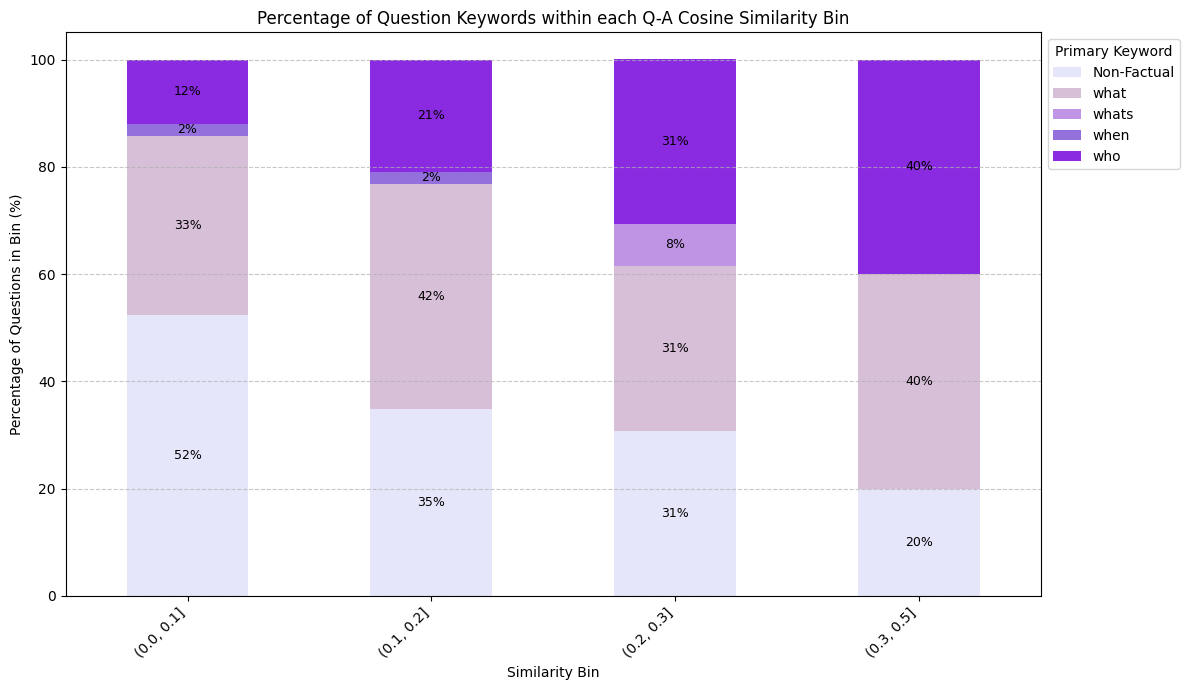

In [79]:
def get_first_keyword_or_na(tag_list):
    if isinstance(tag_list, list) and len(tag_list) > 0:
        return tag_list[0]  # Take the first keyword from the list
    elif tag_list == 'N/A':
        return 'Non-Factual' 
    return 'Other' # Default for unexpected types or empty lists not caught

df_nonzero_qa_similarity['main_keyword_for_grouping'] = df_nonzero_qa_similarity['factual_recall_keyword'].apply(get_first_keyword_or_na)

# Perform the groupby using this new column:
keyword_distribution_by_bin = df_nonzero_qa_similarity.groupby(
    ['similarity_bin', 'main_keyword_for_grouping'], 
    observed=True
).size().unstack(fill_value=0)

keyword_dist_by_bin_percent = keyword_distribution_by_bin.apply(lambda x: (x / x.sum() * 100), axis=1).round(1) 
# Color Palette (shades of purple)
purple_shades = ['#E6E6FA', '#D8BFD8', '#BF94E4', '#9370DB', '#8A2BE2', '#800080', '#4B0082'] 
num_keywords = len(keyword_dist_by_bin_percent.columns)
colors_to_use = purple_shades[:num_keywords] 

# Create the plot and get the Axes object
ax = keyword_dist_by_bin_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7), # Increased height slightly for labels
    color=colors_to_use, # Apply your custom color palette
    title="Percentage of Question Keywords within each Q-A Cosine Similarity Bin"
)
ax.set_ylabel("Percentage of Questions in Bin (%)")
ax.set_xlabel("Similarity Bin") # Added xlabel for clarity
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7) # Added y-axis grid for readability

# Add percentage labels for the stacks for each bin
for i, sim_bin_label in enumerate(keyword_dist_by_bin_percent.index):
    cumulative_height = 0
    # Iterate over each keyword (each segment in the stack for that bin)
    for keyword_col in keyword_dist_by_bin_percent.columns:
        percentage_value = keyword_dist_by_bin_percent.loc[sim_bin_label, keyword_col]

        # Only add label if the percentage is greater than a small threshold (e.g., 1%)
        # to avoid cluttering with tiny labels. Adjust threshold as needed.
        if percentage_value > 1: # You can adjust this threshold
            # Calculate the y position for the label (center of the segment)
            label_y_position = cumulative_height + (percentage_value / 2)
            ax.text(
                i,                             # x-coordinate (bar index)
                label_y_position,              # y-coordinate (center of segment)
                f"{percentage_value:.0f}%",    # Text label (integer percentage)
                ha='center',                   # Horizontal alignment
                va='center',                   # Vertical alignment
                color='black',                 # Label color (adjust if needed for contrast)
                fontsize=9,                    # Font size for labels
            )
        cumulative_height += percentage_value

ax.legend(title='Primary Keyword', bbox_to_anchor=(1, 1), loc='upper left')

fig = ax.get_figure()
plt.tight_layout()
plt.show()

1. Within the trivia dataset, the majority of the records (91%) have no overlap (similarity score = 0) in important keywords between questions and their answers.
2. Of the remaining 9% of dataset with non-zero q-a similarity scores, majority of the scores are in bin 1 (0,0.1]  and bin 2 (0.1,0.2] with 42 and 43 q-a pairs, respectively. This is 82.5% of all the non-zero q-a similarity scores.
3. In bin 1, with the lowest similarity scores, 52% are non-factual questions. These typically can have more open-ended, wordier answers so there is a little overlap in the vocabulary between the question and answers. 
4. As the similarity score increases, the proportion of non-factual questions drops gradually to the lowest in bin 4 with a score range of (0.3, 0.5]. Non-factual account for 20% of the records in the bin and the remainder are factual-recall types. This is likely due to the factual-type questions being tied to their answers and require repeating certain keywords in the answer. For example, the q-a with the highest similarity score share two keywords in common "safe" and "drink". Although technically a "Yes" alone would have been ok but a complete sentence requires repeating words from the question.

The high prevalence of zero or very low Q-A cosine similarity scores, combined with our earlier findings that both questions and answers are typically short, suggests a desirable characteristic for trivia. This means the answers are generally not just rephrasings of the questions. Instead, questions appear to be concise and answers provide specific information often using distinct terminology not explicitly found in the question itself. The overall quality of phrasing, clarity, and correctness will be assessed during the manual review phase.

### 8.2. Question-Question (Q-Q) comparison

In [80]:
# 1. Create a full similarity matrix
qq_similarity_matrix = cosine_similarity(X_questions, X_questions)

In [81]:
n = qq_similarity_matrix.shape[0]
indices_upper_triangle = np.triu_indices(n, k=1)
pairwise_similarity_scores = qq_similarity_matrix[indices_upper_triangle]
scores_series_qq = pd.Series(pairwise_similarity_scores)

desired_percentiles = [0.25, 0.5, 0.65,0.66,0.75, 0.90, 0.95, 0.99]
total_val = len(scores_series_qq)
non_zero_count=scores_series_qq[scores_series_qq !=0].count()

# Print summary
print(f"* Original matrix shape: {qq_similarity_matrix.shape}")
print(f"* Number of unique pairwise scores: {total_val}")
print(f"* {non_zero_count*100/total_val:.1f}% have a non-zero score")
print('\n Descriptive statistics: \n','-'*50)
print(scores_series_qq.describe(percentiles=desired_percentiles).round(4))
print('-'*50)

* Original matrix shape: (1085, 1085)
* Number of unique pairwise scores: 588070
* 34.4% have a non-zero score

 Descriptive statistics: 
 --------------------------------------------------
count    588070.0000
mean          0.0050
std           0.0178
min           0.0000
25%           0.0000
50%           0.0000
65%           0.0000
66%           0.0026
75%           0.0051
90%           0.0131
95%           0.0237
99%           0.0617
max           1.0000
dtype: float64
--------------------------------------------------


#### 8.2.1. Identifying near-duplicate questions with cosine similarity
The question-to-question (Q-Q) cosine similarity, calculated using TF-IDF scores of 1-to-3-word N-grams, showed a sparse relationship matrix. At least 65% of unique question pairs have a similarity score of 0 (with the overall median also being 0), the mean is just 0.005. The standard deviation (0.0178) is larger than the mean indicating that the few non-zero scores have a large spread. Furthermore, 99% of the q-q pairs have a score of 0.062 or less, which is a negligible similarity score. 

The initial idea was to see if any common groupings could be identified in the questions based clustering of the key entities from the TF-IDF vectors. However since the scores are so low it is not worthwile. The additional effort in modelling would negate any gains or insights at this stage. The NER analysis in phase 2 is likely to be a better approach to categorization.

It is interesting to see that the max similarity score is 1.00. This means that there is at least one pair of questions where the wording is identical. These duplicate were somehow missed in the [data preparation section](#4-data-preparation). We need to have a closer look at these rows and then likely drop the redundant ones. 

#### 8.2.2 Approach
A pairwise comparison of the questions with similarity scores close to "1" was used to find the missed (near) duplicates. These questions were missed in the [data preparation](#4-data-preparation) because of small differences between the questions such as capitalization, punctuation, minor wording, typos and other spelling / grammar mistakes (like 'Gamekeeper' vs. 'gamekeeper', or the presence/absence of an article like 'a' or 'the'). When the text is normalized with the tokenizer these differences disappear. 

While this pairwise view highlights many potential duplicates, it doesn't fully capture scenarios where more than two questions are identical. Consider a question 'A' that is identical to question 'B', and B is identical to question 'C', and A and C could be nearly identical but not identified (score=0.998) in the pairwise comparison. However, for the purposes of the game, these near-identical questions are also essentially the same. We've already seen in the data preparation section that there could be 5 copies of a given question. To address this and identify complete sets of duplicate or near-duplicate questions, we will now use a graph-based approach to consolidate these pairwise findings into distinct groups. These groups can then be handled separately and more easily and efficiently than analyzing pairs of questions.

So to summarize, to further investigate the redundancy, the Question-Question (Q-Q) cosine similarity matrix was analyzed using the pairwise comparison and graph analysis sequentially with various similarity score thresholds (1.0, >=0.98, >=0.95, and >=0.90). 

To avoid redundancy,  the results with only a **similarity score of >=0.98** are included here.

##### (i) Pair-wise comparison of questions with a similarity score of 0.98 or more

In [82]:
# 1. get the row and indicies where score is 1 from the qq similarity matrix
threshold_score = 0.8
row_indices, col_indices = np.where(qq_similarity_matrix >= threshold_score)

# 2. Avoid duplicates because of the symmetery of the similarity matrix -> (i,j) vs (j,i) -> store in indices in set when iterating
duplicate_pairs_indices = set()

# 3. Loop through to indicies to get duplicate q ids
for r_idx, c_idx in zip(row_indices, col_indices):
    # Ensure they are different questions AND we only store each pair once
    if r_idx < c_idx: # This condition takes care of i != j and (i,j) vs (j,i)
        duplicate_pairs_indices.add(frozenset((r_idx, c_idx)))

# 4. Display the duplicate question texts
if not duplicate_pairs_indices:
    print("No pairs of different questions found with a similarity score of exactly 1.0.")
else:
    print(f"Found pairs of questions with similarity score of {threshold_score} (potential duplicates):")
    pair_num = 1
    for fs_pair in duplicate_pairs_indices:
        idx1, idx2 = tuple(fs_pair) # Unpack indices from set/frozenset
        
        question1_text = df_for_analysis['question'].iloc[idx1]
        answer1_text = df_for_analysis['answer'].iloc[idx1]
        question2_text = df_for_analysis['question'].iloc[idx2]
        answer2_text = df_for_analysis['answer'].iloc[idx2]

        print(f"\nPair {pair_num}:")
        print(f"  Question {idx1}: {question1_text}")
        print(f"  Answer {idx1}: {answer1_text}")
        print(f"  Question {idx2}: {question2_text}")
        print(f"  Answer {idx2}: {answer2_text}")
        
        pair_num += 1

Found pairs of questions with similarity score of 0.8 (potential duplicates):

Pair 1:
  Question 885: What item in the Headmaster's Office allows you to review bottled memories?
  Answer 885: The Pensieve.
  Question 405: What item in the Headmaster's Office allows you to review bottled up memories?
  Answer 405: The Pensieve

Pair 2:
  Question 662: Where is the entrance to the Chamber of Secrets?
  Answer 662: In the second-floor girl's bathroom, also known as Moaning Myrtle's bathroom.
  Question 263: Where is the entrance to the Chamber of Secrets?
  Answer 263: Moaning Myrtle's bathroom

Pair 3:
  Question 752: Who is Harry Potter's godfather?
  Answer 752: Sirius Black
  Question 894: Who is Harry Potter's godfather?
  Answer 894: Sirius Black.

Pair 4:
  Question 570: Do you know what kind of creature a Boggart is?
  Answer 570: Non-being
  Question 340: Do you know what kind of creature a Boggart is? Because I [Merula] do.
  Answer 340: Non-being

Pair 5:
  Question 16: Cedric

##### (ii) Graph analysis to find more near-duplicates from the pair-wise results

In [83]:
# duplicate_pairs_indices is a list of (idx1, idx2) tuples
# 1. Initialize the graph object
G = nx.Graph()

# 2. Add edges to each node. 
# `duplicate_pairs_indices` is a list of (idx1, idx2) tuples. The node represents a question the added edge the connection (similarity score = 1).
G.add_edges_from(duplicate_pairs_indices) # Add all question indices involved as nodes too

# 3. Create group of copies by grouping connections together. So here A=B and B=C would be in the same group.
# duplicate_groups will be a list of sets, e.g., [{662, 263}, {752, 894, 791}, ...]
duplicate_groups = list(nx.connected_components(G))

# 4. Display results in a similar format to the pairwise comparison so we can visually confirm the results.

# Initialize a counter for the group number
group_number = 1
# Loop through the groups and print results
for group in duplicate_groups:
    if len(group) > 1: # Only interested in actual groups of duplicates
        print(f"\n--- Duplicate Group {group_number} (Size: {len(group)}) ---")
        for question_index in sorted(list(group)): # Sort for consistent display
            question_text = df_for_analysis['question'].iloc[question_index]
            answer_text = df_for_analysis['answer'].iloc[question_index]
            print(f"  Question {question_index}: {question_text}")
            print(f"  Answer {question_index}:   {answer_text}")
            
        group_number += 1 


--- Duplicate Group 1 (Size: 3) ---
  Question 405: What item in the Headmaster's Office allows you to review bottled up memories?
  Answer 405:   The Pensieve
  Question 569: What item in the Headmaster's Office allows you to review bottled memories?
  Answer 569:   The Pensieve
  Question 885: What item in the Headmaster's Office allows you to review bottled memories?
  Answer 885:   The Pensieve.

--- Duplicate Group 2 (Size: 3) ---
  Question 263: Where is the entrance to the Chamber of Secrets?
  Answer 263:   Moaning Myrtle's bathroom
  Question 662: Where is the entrance to the Chamber of Secrets?
  Answer 662:   In the second-floor girl's bathroom, also known as Moaning Myrtle's bathroom.
  Question 937: Where is the entrance to the Chamber of Secrets hidden?
  Answer 937:   The girls' bathroom

--- Duplicate Group 3 (Size: 3) ---
  Question 752: Who is Harry Potter's godfather?
  Answer 752:   Sirius Black
  Question 791: Who was Harry Potter's godfather?
  Answer 791:   Siri

#### 8.2.3. Results

Questions with a similarity score of 1.0 represented items that became identical after the text normalization (e.g., due to capitalization or minor punctuation differences). For example, some identical questions show minor answer variations like punctuation differences (e.g., one answer ending with a full stop, another not) or semantic equivalencies (e.g., an answer being "Seven" versus "7"). In other cases, truly identical questions are paired with slightly different answer phrasings or levels of detail, all of which require careful review. Expanding the threshold to >=0.98 included these, plus a few additional pairs representing very strong paraphrases or extremely minor textual variations (e.g., "bottled memories" vs. "bottled up memories"). Interestingly, further lowering the threshold to >=0.95 and then to >=0.90 did not identify any new pairs beyond those already captured. 

This suggests that the max score of "1"  will disappear once the duplicates are removed. The 99% score (0.0617) would then be the max. So it can be generalized that the similarities between the questions is negligible. This shows that the dataset is diverse and has non-repeating quesions.
  
With a threshold score of 0.98, the pairwise comparison identified 40 pairs of questions. When these pairs were input to the graph analysis, 32 distinct groups (68 unique questions) were flagged for manual evaluation. The question groups can be categorized into four groups:
1. Identical or near identical questions and answers - minor differences such as capitalization or stop words (groups 1-3, 5-13, 15-20, 26-32),
2. Identical questions with semantically similar answers - the answers are slightly different for example "7" vs. "seven" (groups 4, 14, 23)
3. Identical questions but different answers - questions with different phrasing or even completely different (groups 22, 24, 25)
4. Identical questions by a typo in the answer - both answers are correct but one spelt incorrectly (group 21).

Since there is an overlap between the q-q and a-a analysis, the redundant questions will be handled now rather then flagged and dealt collectively in the [manual review section](#10-data-quality-assurance-and-finalization). This is because it will introduce noise into the a-a similarity comparison. It will be hard to distinguish which answers are repeated but from different questions (different questions can ask about the same character, e.g. Dumbledore or Hermione) or because of the duplicates are still present in the dataset. 

#### 8.2.4. Action plan to handle redundancy

**Guiding principles**:
- concise, correct, and clear questions and answers. Use the best canonical answer
- Appropriate trivia question - make sure they make sense in the gameplay.
- player / game experience - fairness, variety, interesting, reasonable level of difficulty.
- standardization - questions like mcq, true/false, and fill in the blank have a set approach in phrasing. Consistent format, makes the dataset more navigable. Answer standardization e.g. answers like "Seven" are standardized to "7" (as strings).

**Outcome**:
The manual review of the 32 groups identified a total of 42 unique questions for removal. Of these:
- 2 groups (group no. 13, 23 with 2 questions each) were removed without replacement because they were not appropriate trivia questions (joke or too vague).
- 4 groups were removed completely but will be replaced by 4 new questions. This was typically because it was either an incomplete multiple-choice question or the answer was too ambiguous (groups 6, 12, 24, 26). This was also an opportunity to standardize the format of multiple-choice questions.
- for the remaining groups, one question was selected from each group and the remaining were deleted.

The detailed action plan can be found here. 

>pipeline to transform dataset?

Based on the action plan, we can create a list of the questions that need to be dropped:

In [84]:
# Question 460 before dropping for sanity check
df_tfidf_cs.iloc[460]

question                  Which of these is not a form of Transfiguration?
answer                                                         Enchantment
question tokens                             [which, form, transfiguration]
answer tokens                                                [enchantment]
combined_unique_tokens         [which, form, transfiguration, enchantment]
factual_recall_keyword                                                 N/A
all_keywords_str                    which form transfiguration enchantment
question_tokens_str                             which form transfiguration
answer_tokens_str                                              enchantment
Name: 460, dtype: object

In [85]:
# List of questions identified for removal based on the q-q similarity analysis (32 distinct groups, 42 questions in total)
qlist_to_delete = [405, 885, 263, 752, 894, 432, 93, 460, 697, 1055,
                   1043, 397, 73, 425, 261, 271, 433, 203, 259, 268, 
                   1075, 1045, 505, 343, 731, 625, 1080, 235, 113, 667,
                   123, 499, 1020, 212, 446, 219, 658, 719, 64, 95, 
                   890, 1054]

# delete from the df_tifidf_cs DataFrame
print(f"Number of questions before removing duplicates: {df_tfidf_cs.shape[0]}")
df_tfidf_cs = df_tfidf_cs.drop(index=qlist_to_delete).reset_index(drop=True)
# sanity check
print(f"Number of questions after removing duplicates: {df_tfidf_cs.shape[0]}")

Number of questions before removing duplicates: 1085
Number of questions after removing duplicates: 1043


In [86]:
# Sanity check - Q.460 after deleting
df_tfidf_cs.iloc[460]

question                     What spell transforms an object into a Portkey?
answer                                                                Portus
question tokens                   [what, spell, transforms, object, portkey]
answer tokens                                                       [portus]
combined_unique_tokens    [what, spell, transforms, object, portkey, portus]
factual_recall_keyword                                                [what]
all_keywords_str                 what spell transforms object portkey portus
question_tokens_str                     what spell transforms object portkey
answer_tokens_str                                                     portus
Name: 460, dtype: object

In [87]:
# 5. Transform the columns with the vectorizer
Z_questions = vectorizer.transform(df_tfidf_cs['question_tokens_str'])
qq_similarity_matrix_cleaned = cosine_similarity(Z_questions, Z_questions)

n = qq_similarity_matrix_cleaned.shape[0]
indices_upper_triangle = np.triu_indices(n, k=1)
pairwise_similarity_scores_cleaned = qq_similarity_matrix_cleaned[indices_upper_triangle]
scores_series_qq_cleaned = pd.Series(pairwise_similarity_scores_cleaned)

desired_percentiles = [0.25, 0.5, 0.65,0.66,0.75, 0.90, 0.95, 0.99]
total_val = len(scores_series_qq_cleaned)
non_zero_count=scores_series_qq_cleaned[scores_series_qq_cleaned !=0].count()

# Print summary
print(f"* Original matrix shape: {qq_similarity_matrix_cleaned.shape}")
print(f"* Number of unique pairwise scores: {total_val}")
print(f"* {non_zero_count*100/total_val:.1f}% have a non-zero score")
print('\n Descriptive statistics: \n','-'*50)
print(scores_series_qq_cleaned.describe(percentiles=desired_percentiles).round(4))
print('-'*50)

* Original matrix shape: (1043, 1043)
* Number of unique pairwise scores: 543403
* 34.7% have a non-zero score

 Descriptive statistics: 
 --------------------------------------------------
count    543403.0000
mean          0.0049
std           0.0155
min           0.0000
25%           0.0000
50%           0.0000
65%           0.0000
66%           0.0028
75%           0.0051
90%           0.0130
95%           0.0233
99%           0.0602
max           0.8728
dtype: float64
--------------------------------------------------


### 8.3. Answer-Answer (A-A) comparison

In [88]:
# 1. Create a full similarity matrix
aa_similarity_matrix = cosine_similarity(Y_answers, Y_answers)

In [89]:
n = aa_similarity_matrix.shape[0]
indices_upper_triangle = np.triu_indices(n, k=1)
aa_pairwise_similarity_scores = aa_similarity_matrix[indices_upper_triangle]
scores_series_aa = pd.Series(aa_pairwise_similarity_scores)

desired_percentiles = [0.25, 0.5, 0.65,0.66,0.75, 0.90, 0.95, 0.99]
total_val_aa = len(scores_series_aa)

# Print summary
print(f"* Original matrix shape: {aa_similarity_matrix.shape}")
print(f"* Number of unique pairwise scores: {total_val_aa}")
print('\n Descriptive statistics: \n','-'*50)
print(scores_series_aa.describe(percentiles=desired_percentiles).round(4))
print('-'*50)

* Original matrix shape: (1085, 1085)
* Number of unique pairwise scores: 588070

 Descriptive statistics: 
 --------------------------------------------------
count    588070.0000
mean          0.0010
std           0.0253
min           0.0000
25%           0.0000
50%           0.0000
65%           0.0000
66%           0.0000
75%           0.0000
90%           0.0000
95%           0.0000
99%           0.0000
max           1.0000
dtype: float64
--------------------------------------------------


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 9. Feature Engineering from In-depth EDA Findings

## 9.1. Dataset cleaning based on findings from in-depth EDA

**Task list:**
1. Delete Q.(1271. Q:"Will you serve the great nation of Peevesland, soldier?" - A:"Sir, yes, sir!")
2. Delete duplicate (Q. 644 & 1228 are identical and missed in earlier cleaning).
3. Edit Q. 667 (Fill in the blank: Petrificus Totalus is the incantation for the Full Body-Bind curse.) -> no missing blanks, (A: Bind (Got this in the Petrificus Totalus lesson.)) --> change to [Q: "Fill in the blank: Petrificus Totalus is the incantation for the full ____-_____ curse." / A:"Body-bind"]
4. Q.230 looks incomplete - need to have a look at question before or after in case if it was somehow split across rows?
5. Q.590 "Who do you prefer: Dust, Binns, or Peeves?" nonsensical - delete.
6. Q.861 "Who is NOT in Slytherin: Lavender Brown, Pansy Parkinson, Blaise Zabini, or Gregory Goyle?" - MC question
7. Q.198 / 921 / 372 / 796 = Multiple choice
8. Q.111 Typo "What is a potion that cause boils *of* brewed incorrectly?" -- should be if.
9. Q.1214 - incomplete multiple choice question

In [90]:
## Updated keyword lists for searching different types of questions.

# Factual recall: expanded list of words to look for when identifying 'factual recall' questions 
expanded_factual_recall_list = ['what', 'name', 'who', 'where', 'wheres', 'when', 'whats', 'whose','which']

# Open-ended: new list
open_ended_list = ['why', 'how']

# Yes/No: new list
# in questions: 
yesno_question_start_keywords = ['is', 'are', 'was', 'were', 'do', 'does', 'did', 'can', 'could', 'has', 'had', 'will', 'would', 'should','True', 'False'] # in question
# validation check with answers
yesorno_list_forans = ['True', 'False', 'Yes', 'No'] # in answer

## 9.2 Add question-type tags to dataset

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

<div align="center" style="background-color: #f0e6f7; padding: 10px;">
    <span style="color:purple; font-size:32px;">Part 4: Quality assurance and finalization</span>
</div>

# 10. Data quality assurance and finalization

## 10.1. Automated heuristics

1. Readability Scores:
- What: Calculate standard readability scores (e.g., Flesch Reading Ease, Flesch-Kincaid Grade Level) for both the question and answer text columns. Libraries like textstat make this straightforward.
- Why: This gives you a quantitative measure of linguistic complexity. While not a direct measure of correctness or difficulty, very high or very low scores, or large discrepancies between question and answer readability, might flag items for closer inspection during manual review. It adds objective metrics about text complexity.
- Fit for Phase 1: Yes, calculation is simple and fast.

2. Outliers - questions / answers that are very long or very short (could indicate truncated data) etc

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 10.2. Manual review

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 10.3. Status map of the dataset

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

<div align="center" style="background-color: #f0e6f7; padding: 10px;">
    <span style="color:purple; font-size:32px;">Part 5: Dataset preparation for export to CLI-MVP</span>
</div>

# 11. Summmary and key findings

## 11.1. Summary

Answer lengths:
- Majority of the answers are 

- Signifiant analysis and categorization of the questions types was achieved just by tokenizing the question and answers and looking at the question syntax. The trivia dataset follows question pattern of what can typically be expected and could be categorized into question types.
- The vast majority of the questions are factual-recall type (97%).  The answers to factual-recall type questions are relatively simpler to analyze for correctness.
- Of the 97%, majority (49%) of the factual-recall types use 'what' as a keyword to pharse the question. 
- There are other question formats in the dataset as well:
    - True / False or Yes / No -> binary choice
    - Fill in the blank
    - open-ended or explanatory
    - question written as statements
- There were no multiple-choice questions.
- There were also spelling mistakes and problematic (nonsensical) questions that needed to be cleaned. 
- A design decision was made not to modify or remove the uncategorized questions.
- The dataset right now is sufficient for the CLI-MVP.
- However, the data analysis so far has not taken into account 'Harry Potter' specific content. This will be tackled specifically in the next project phase using custom NER classes.

>📝 **Note**: 
> 
>Understanding the dataset's answer diversity by analyzing keyword uniqueness and semantic similarity (e.g., 'Albus' vs 'Dumbledore') is important for assessing content variety and refining the requirements for the player answer semantic comparison logic. This specific dataset analysis will be undertaken in Phase 2, synergistic with NER efforts, allowing the current phase to focus on the MVP's core game loop and initial answer evaluation setup.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 11.2. Key findings

1. 97%+ successful categorization even before NER work - excellent success metric.
2. Similar contextual, "Harry Potter" centric categorization will help enrich the game experience and help make it more immersive.
2. The main distinguishing factor for questions in the dataset is whether they are 'factual-recall' type or not. These question types generally have straight forward answers. Answer comparison with user input should be relatively straight forward for the MVP.
4. When growing the dataset for next phases 
    - can balance the other question type categories (especially open-ended, nuanced questions to make NLP features shine)
    - add multiple choice questions especially for easy mode
    - Can also balance the categories within the 'factual-recall' - this will help with medium / difficult levels.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

<div align="center" style="background-color: #f0e6f7; padding: 10px;">
    <span style="color:purple; font-size:32px;">Part 5: Finalizing dataset for CLI-MVP</span>
</div>

# 12. Data dictionary

1. Data dictionary table
2. Json conversion for the csv

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 13. Next steps and data export

The next steps based on the work completed in this notebook:

1. **CLI MVP Input:** <br>
The dataset generated here, containing the cleaned trivia questions/answers and extracted keywords (from the second checkpoint), serves as the primary data source for the current command-line interface (CLI) MVP of the trivia game. 

2.  **Further Feature Enhancement (NER):**<br>
 The next phase of data enrichment involves applying Named Entity Recognition (NER) to potentially classify questions or extract structured information like difficulty and category. This work is planned for the [NER Implementation notebook](03-NER_implementation.ipynb)

 The processed dataset is ready to be exported for the CLI-MVP.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

---

#### 💾 Checkpoint 2: Phase-1 CLI-MVP dataset 

Saving clean dataset with keywords and question type tags
<details>
<summary> Click here for checkpoint details and <b>warning!</b> </summary>

The DataFrame is now cleaned, EDA completed, with the keywords and question-type features columns. Saving the current state.
<br>
> **⚠️ Caution: Manual Intervention Required for Saving Files**
>
> Please be aware that the `save_dataframe_to_csv` utility is designed to prevent accidental data loss. It **does not automatically overwrite** previously saved files.
>
> If you run a cell that calls this function and the output file (based on `filename_base`, `version`, and `subfolder`) already exists, the save operation will be skipped. You will see a message indicating this.
>
> **To save your latest data, you must manually intervene by either:**
> 1.  Deleting the older version of the CSV file from the file system.
> 2.  Modifying the `version` argument (or `filename_base`) in your function call to create a new, unique filename.

The following code saves the cleaned DataFrame to <code>data/project_datasets/</code> based on the selected `Save arguments` in the code below.
</div>
</details>

In [91]:
# Using utils.paths.py module -> prevents overwritting csv file unless manually done.

# Save arguments
# dataframe_to_save = 
name_for_csvfile = 'CLI-MVP_trivia_dataset'
csv_version = 'v0'
csv_subfolder = 'project_datasets'

# Save csv  file with custom functions and defined save arguments
# up.save_dataframe_to_csv(dataframe_to_save, name_for_csvfile, csv_version, csv_subfolder)

---

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#1-introduction" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Return to the Top</a>

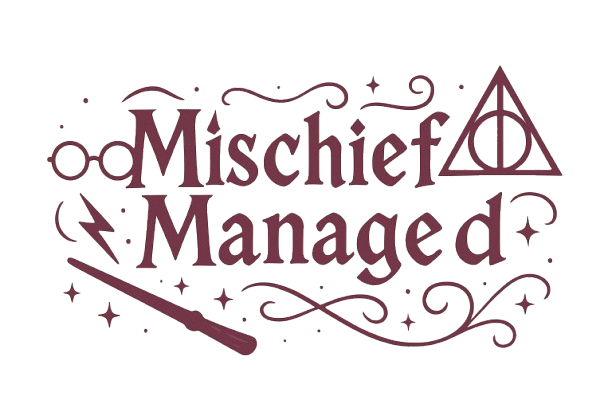